---
title: Task-structure preferences
author:
  - name: Alex Lepauvre
    orcid: 0000-0002-4191-1578
    corresponding: true
    email: alex_francois.lepauvre@tu-dresden.de
    roles: []
    affiliations:
      - Chair of Cognitive Computational Neuroscience, Faculty of Psychology, TUD Dresden University of Technology, Dresden 01187, Germany
  - name: Stefan Kiebel
    orcid:  0000-0002-5052-1117
    corresponding: false
    roles: []
    affiliations:
      - Chair of Cognitive Computational Neuroscience, Faculty of Psychology, TUD Dresden University of Technology, Dresden 01187, Germany
keywords:
  - Decision making
  - Reinforcement learning
abstract: |
  []
date: last-modified
number-sections: true
bibliography: references.bib
---

## Introduction

A central idea in Bayesian accounts of perception and sensorimotor control is that the brain does not rely on current sensory evidence alone [@knill2004bayesian;@lee2003hierarchical;@rao1999predictive;@clark2013whatever;@friston2010free]. Sensory evidence is often noisy, incomplete, or costly to acquire with high precision: better evidence may require more time, attention, sampling, or specialized processing. The Bayesian solution is to combine current evidence with prior information derived from experience and the statistical structure of the environment. As formulated in the ‘Bayesian brain hypothesis’, the influence of prior information should depend on uncertainty: when current evidence is unreliable, behavior should rely more strongly on the prior. Conversely, when current evidence is reliable, it should dominate behavior. For example, @kording2004bayesian provided a canonical demonstration of this principle, showing that participants combine learned priors with sensory feedback according to their relative uncertainty.

We propose that an analogous principle applies to planning-based decision making. In this case, the role of sensory evidence is taken by an internally generated estimate of action value. In sequential decision tasks, such estimates can be generated by internal forward planning, which provides state-specific information about the long-value of choosing an action. However, generating these estimates is computationally costly because it requires evaluating future outcomes in complex and dynamic environments. In analogy to the Bayesian view on perception, agents may therefore combine their estimates derived from costly forward planning, with stored prior information about which actions are usually appropriate in a given task. This idea has been applied previously in a Bayesian account of the balance between habitual and goal-directed control, in which habitual tendencies were modelled as priors over policies that are balanced against goal-directed information about current outcome contingencies [@schwobel2021balancing;@schwobel2024joint]. This approach resonates with resource-rational accounts of planning, which postulates that the brain adapts its planning computations to the costs and benefits of using its relatively limited cognitive resources [@gershman2015computational;@lai2021policy;@lai2024human]. 

Following these previous accounts, we assume that choices in complex sequential decision making reflect the integration of two sources of information about action. First, participants have acquired task-structured preferences that reflect regularities in the task structure and their own experience within the task. Second, as is typically modelled in reinforcement learning, for each trial, participants use forward planning to derive values for each available action in an online fashion. These values are computationally costly and represent state-specific evidence for each action. Assuming a Bayesian approach, we hypothesize that these two sources are integrated by weighting the contribution of planning against preferences by their respective uncertainties. This hypothesis implies that strong preferences should guide choices and produce faster responses because less planning is needed. Weak or uncertain preferences should increase reliance on forward planning and make choices more sensitive to planning-derived DV and produce longer response times because of the involved computations.

In this paper, we test this hypothesis in a complex sequential decision-making task, using model comparisons and response-time analyses. We compare models in which choice variability is explained by recent action frequencies, coarse contextual divisions of the state space, or structured preferences derived from task features. Our results show that participants’ choices are best captured by a model that combines planning-derived DV with state-dependent preferences constructed from multiple task features. We further show that these preferences interact with planning such that choices are guided more strongly by planning when preferences are weak, and more strongly by preferences when they are decisive. Together, these findings suggest that human sequential decision making reflects the integration of costly planning with structured, task-informed preferences that simplify action selection.

In [85]:
# Import all packages

# General utilities:
import os 
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings
import matplotlib.colors as mcolors

# Stats
import pymc as pm
import arviz as az
import bambi as bmb
from scipy.special import logit, expit
from scipy.stats import pearsonr

# Custom packages:
from stabst.MarkovDecisionProcess import MDP
from stabst.TaskConfig import LimitedEnergyTask
from stabst.utils import avg_reduce_mdp, abstract2ground_value

A4_inches = [8.27-0.5,11.69-0.5]

def make_grid(dv_min, dv_max, pref_min, pref_max):
    """
    Makes a 2D grid reflecting the limits of our modelled variables (preferences and DV)
    Parameters
    ----------
    dv_min : _type_
        _description_
    dv_max : _type_
        _description_
    pref_min : _type_
        _description_
    pref_max : _type_
        _description_

    Returns
    -------
    _type_
        _description_
    """
    x1_grid = np.linspace(start=dv_min, stop=dv_max, num=300)
    x2_grid = np.linspace(start=pref_min, stop=pref_max, num=300)
    x1_mesh, x2_mesh = np.meshgrid(x1_grid, x2_grid)
    x_grid = np.stack(arrays=[x1_mesh.flatten(), x2_mesh.flatten()], axis=1)
    return x1_grid, x2_grid, x_grid

# Define custom functions:
# Choice behaviour model with preferences and DV:
def preference_model(
        y: np.array,
        decision_values: np.array,
        pref_regressors: pd.DataFrame,
        subject_index: np.array,
        subject_labels: np.array      
):
    '''
    Parameters
    ----------
    y : np.array [N samples, ]
        Observed binary data (1, 0...)
    decision_values : np.array [N samples, ]
        DV to regress onto the observed data
    pref_regressors : np.array [N samples, M regressors]
        Regressor to fit participants preference for. We can have M regressors
    subject_index : np.array  [N samples, ]
        Index of the subject associated with each observation
    subject_labels : np.array  [N subjects, ]
        Single identifier of each subject
    coords : dict  
        "subject": subj_labels, 
        "coef": ["intercept", "slope"],
        The subject maps the data to each subject, the coef are for the coefficients
    b_prior_mean : Optional[float], optional
        Prior mean of each beta parameters, by default 0
    b_prior_sigma : Optional[float], optional
        Prior variance of the population level distribution of the beta, by default 2
    s_prior_sigma : Optional[float], optional
        Prior between subjects variance, by default 2
    n_drawss : Optional[int], optional
        Number of draws for the posterior, by default 1000
    n_tuning_draws : Optional[int], optional
        Number of tuning draws, by default 1000
    Returns
    -------
    tuple[pm.Model, arviz.InferenceData]
        pm.model : pymc model object
        idata : arviz inference data
    '''
    # Get dimensions:
    n_obs = y.shape[0]
    n_groups = subject_labels.shape[0]
    n_pref = pref_regressors.shape[1]

    # Create intercept:
    intercept = np.ones(n_obs)

    # Set coordinates:
    coords = {
        "subject": subject_labels,
        "coef_intercept": ["B_intercept"],
        "coef_planning": ["B_plan"],
        "coef_pref": ["B_" + col for col in pref_regressors.columns],
        "coef_interaction": ["slope"],
    }


    # Model:
    with pm.Model(coords=coords) as planning_preferences_interaction_model:
        # Data:
        y_obs = pm.Data("y_obs", y)
        intercept = pm.Data("intercept", intercept)
        planning = pm.Data("planning", decision_values)
        preferences = pm.Data("preferences", pref_regressors)
        subj_idx = pm.Data("subj_idx", subject_index.astype("int32"))

        # Hyperpriors:
        # Intercept term
        beta_intercept = pm.Normal("beta_intercept", mu=0, sigma=2, dims="coef_intercept")
        sigma_intercept = pm.HalfNormal("sigma_intercept", sigma=2, dims="coef_intercept")
        # Planning term:
        beta_planning = pm.Normal("beta_planning", mu=0, sigma=2, dims="coef_planning")
        sigma_planning = pm.HalfNormal("sigma_planning", sigma=2, dims="coef_planning")
        # Preference terms:
        beta_pref = pm.Normal("beta_pref", mu=0, sigma=2, dims="coef_pref")
        sigma_pref = pm.HalfNormal("sigma_pref", sigma=2, dims="coef_pref")
        # Interaction term:
        beta_interaction = pm.Normal("beta_interaction", mu=0, sigma=2, dims="coef_interaction")
        sigma_interaction = pm.HalfNormal("sigma_interaction", sigma=2, dims="coef_interaction")

        # Offset parameters:
        z_intercept = pm.Normal("z_intercept", 0, 1, dims=("subject", "coef_intercept"))
        z_planning = pm.Normal("z_planning", 0, 1, dims=("subject", "coef_planning"))
        z_biases = pm.Normal("z_biases", 0, 1, dims=("subject", "coef_pref"))
        z_interaction = pm.Normal("z_interaction", 0, 1, dims=("subject", "coef_interaction"))

        # Centered parameters:
        beta_intercept_sub = pm.Deterministic("beta_intercept_sub", beta_intercept + z_intercept * sigma_intercept, 
                                              dims=("subject", "coef_intercept"))
        beta_planning_sub = pm.Deterministic("beta_planning_sub", beta_planning + z_planning * sigma_planning, 
                                             dims=("subject", "coef_planning"))
        beta_pref_sub = pm.Deterministic("beta_pref_sub", beta_pref + z_biases * sigma_pref, 
                                         dims=("subject", "coef_pref"))
        beta_interaction_sub = pm.Deterministic("beta_interaction_sub", beta_interaction + z_interaction * sigma_interaction, 
                                                dims=("subject", "coef_interaction"))
        
        # Estimate the score of the bias (i.e. weighted sum of each of the biases regressors):
        preference = pm.Deterministic('preference', (beta_pref_sub[subj_idx] * preferences).sum(axis=-1))
        
        # Convert the bias back onto probability space:
        pi_prior = pm.Deterministic("pi_prior", pm.math.sigmoid(preference))

        # Compute the entropy:
        entropy = pm.Deterministic("entropy", -pi_prior * pm.math.log(pi_prior) - (1-pi_prior) * pm.math.log(1 - pi_prior))
        
        # Eta parameter is the weighted sum of the intercept, the bias, the planning values and 
        # the interaction between the entropy of the bias and the planning
        eta = (
            beta_intercept_sub[subj_idx, 0] * intercept
            + preference
            + beta_planning_sub[subj_idx, 0] * planning
            + beta_interaction_sub[subj_idx, 0] * (entropy * planning)
        )
        
        # Expected values:
        p = pm.Deterministic("p", pm.math.sigmoid(eta))

        # Likelihood 
        pm.Bernoulli("y", p=p, observed=y_obs)

        # Sampling:
        idata = pm.sample(
            draws=n_samples,
            tune=n_warmup,
            chains=n_chains,
            target_accept=0.85,
            idata_kwargs={"log_likelihood": True},
        )
        # Sample posterior predictive for later model checking:
        idata.extend(pm.sample_posterior_predictive(idata, var_names=["p", "y"]))
    return idata

def linear_decay_mvavg(arr, window_size, init_val = 0.5):
    '''
    Compute the moving average of a 1D array with a specified window size and 
    linear decay
    '''
    # Pad the array with initial value
    arr = np.pad(arr.astype(float), (window_size - 1, 0), constant_values=init_val)
    # Generate kernel:
    kern = np.arange(window_size)/np.sum(np.arange(window_size))
    return np.convolve(arr, kern, mode='valid')

def predict_responses(dv, pref, idata):
    """_summary_

    Parameters
    ----------
    dv : _type_
        _description_
    pref : _type_
        _description_
    beta_plan : _type_
        _description_
    beta_interaction : _type_
        _description_
    """
    # Compute the preferences entropy:
    p_pref = expit(pref)
    entropy = -p_pref * np.log(p_pref) - (1-p_pref) * np.log(1 - p_pref)
    # Extract the betas:
    b_plan = idata.posterior["beta_planning"].mean().data
    b_interaction = idata.posterior["beta_interaction"].mean().data
    return expit(b_plan * dv + pref + b_interaction * dv * entropy)

def truncate_colormap(cmap, min_val=0.0, max_val=1.0, n=256):
    """Slice a colormap to the sub-range [min_val, max_val]."""
    colors = cmap(np.linspace(min_val, max_val, n))
    return mcolors.LinearSegmentedColormap.from_list(
        f"{cmap.name}_trunc({min_val:.2f},{max_val:.2f})", colors
    )

# Set random seed for reproducibility:
np.random.seed(42)
warnings.filterwarnings("ignore")

n_samples = 1000
n_warmup = 1000
n_chains = 4

In [86]:
# Download the data if needed:
if not os.path.exists('./data/raw_data/all_participants_data.csv'):
    if not os.path.exists('./data/raw_data'):
        os.makedirs('./data/raw_data')
    url = 'https://raw.githubusercontent.com/fmott/context_dependent_planning/4d239b721749adabb8fe8f1d8ac2d1ecdeba17cf/data/behaviour/data_all_participants_20220215120148.csv'
    os.system(f'wget {url} -O ./data/raw_data/all_participants_data.csv')
if not os.path.exists('./data/raw_data/all_participants_age_gender.csv'):
    if not os.path.exists('./data/raw_data'):
        os.makedirs('./data/raw_data')
    url = 'https://raw.githubusercontent.com/fmott/context_dependent_planning/4d239b721749adabb8fe8f1d8ac2d1ecdeba17cf/data/behaviour/age_gender.csv'
    os.system(f'wget {url} -O ./data/raw_data/all_participants_age_gender.csv')
# Load the data:
beh_data = pd.read_csv('./data/raw_data/all_participants_data.csv')
demographic_data = pd.read_csv('./data/raw_data/all_participants_age_gender.csv', sep=";")

# Extract demographic information:
n_participants = demographic_data.shape[0]
n_female = demographic_data['gender (m = 1, f = 2)'].value_counts()[2]
mean_age = demographic_data['age'].mean()
std_age = demographic_data['age'].std()

# ===================================================================
# Data preprocessing:
# Remove nans:
beh_data = beh_data.dropna()
# Remove timeout:
beh_data = beh_data[beh_data["timeout"] == 0]
# Flip responses: 1 = accept:
beh_data["response"] = (beh_data["response"] == 0).astype(int)
# Make trial 1 based
beh_data["trial"] = beh_data["trial"] + 1
# Generate future cost based on the transitions:
transitions_costs = {
    0: [1, 1],
    1: [2, 1],
    2: [1, 2],
    3: [2, 2]
}
beh_data["fc"] = [transitions_costs[row["transition"]][1] for _, row in beh_data.iterrows()]


## Methods

### Data
To test our hypothesis, we reused data from a previously published study by @ott2022forward and colleagues, in which `{python} f"{n_participants:.0f}"` participants (`{python} f"{n_female:.0f}, mean age={mean_age:.1f}, SD={std_age:.1f}"`) took part in a sequential decision making task [@ott2022forward;@ott2022forward-data]. The study was approved by the Institutional Review Board of the Technische Universität Dresden and conducted in accordance to ethical standards of the Declaration of Helsinki.

@fig-design shows a schematic representation of the task. Participants were instructed to gather as many points as possible throughout the task. In each trial, they were presented with offers associated with a reward of 1, 2, 3 or 4 points which they could either accept or reject. To accept an offer, participants had to pay an energy cost of either 1 or 2 energy points (low cost, LC and high cost, LC segments respectively). When they rejected the offer, they gained 1 energy point. Participants energy level was capped at 6, so their energy could range from 0 (depleted energy) to 6 (max energy). Offers varied in each trial following a uniform distribution (equal probability of each offer in each trial). Costs remained fixed for 4 conscecutive trials, which we refer to as a segment, and participants were informed of the price of the current 4 trials and future 4 trials. The costs of the segment beyond the current horizon was randomly picked such that each costs transitions (from current high or low cost to future high or low cost) were equally probable throughout the experiment. When participants accept an offer that they cannot afford (current energy level below current cost), no reward was awarded and a warning was displayed.

![Experimental design: (A) Single trial procedure, each frame represents a step within the trial with duration of each step above. Top row depicts participants accepting, bottom row depicts participants rejecting. In each trial, participants are presented with N golden cups, the number of cups symbolizes the amount of reward. The blue bar represents energy level, they yellow bar represents accumulated reward so far, lightning symbols at the bottom right of each frame represent current cost (left) and future cost (right). (B) Between trial costs dependencies. A segment consists of 4 trials within which cost is fixed, and participants are aware of the cost in the current and future 4 trials but not beyond. (C) Transition structure. Cost can transition from low cost (LC) to high cost (HC), LC to LC, HC to LC and HC to HC. Reproduced from @ott2022forward](images/experimental_design.jpg){#fig-design fig-alt="Experimental design"}

Accordingly, participants had to decide whether to accept or reject an offer based on the current offer and cost ratio. They also had to take into account the impact of their current decision on their future capabilities to accept offers, as systematically accepting offer will deplete energy fast, hindering their capacity to collect more reward. Therefore, maximizing overall return is non trivial in this task and requires complex planning. 

The temporal structure of the trials was as follows. In the beginning of each trial, a fixation cross was presented for 0.5s in the middle of the screen. Then, an offer appeared represented by the number of "cups" presented in the middle of the screen and choice options were presented on each sides of the screen, surrounded by a black frame. Participants had 5s to provide an answer, by selecting one or the other options (accept or reject), in which case the frame around the chosen option disappeared. Following their choice, the resulting change in energy and points were displayed (green indicating an increase in point and/or energy, red indicating a decrease in energy) for 1s. The trial ended with an inter-trial interval (ITI) ranging from 2 to 5s (uniformly sampled, rounded to the first decimal) in which the offer disappeared and unframed choice options remained on screen. If participants took longer than 5s to provide their answer, a warning message was displayed and the next trial started. 

To familiarize themselves with the task, participants conducted a training session of 144 trials, corresponding to 36 segments. Participants then conducted the experiment consisting of 240 trials (60 segments). The test session was performed in a fMRI scanner, while the training session was performed outside of it. In both cases, participants started with an energy budget of 3, and their reward points were accumulated throughout the entire experiment. Trial sequence was pseudorandomized, such that each costs transitions (LC to LC, LC to HC, HC to LC and HC to HC, see figure @fig-design) occured equally often within the training and test sessions, resulting in 9 repetition of each transition in the training session and 15 in the experiment. In addition, the offer were sampled to be equally distributed within each transition. The sequence of costs transitions and offers was kept the same across participants. Participants were offered two to three minutes breaks inside the scanner every 20 segments. The test sessions lasted around 40min. 

### Forward planning component
To model optimal behaviour in the task, we operationalized our task as a Markov Decision Process (MDP) with the following tuples:

$$
MDP = (S, A, P, R)
$$

Where $S$ represent all possible states in our task, where each state $s$ consists of a combination of the experimental variables in our task:  $S=E \times O \times CC \times FC \times T$, with energy $E={0, 1, ..., 6}$, offer $O={1, 2, 3, 4}$, current segment cost $CC={1, 2}$, future segment cost $FC={1, 2}$ and trial $T={1, 2,..., 13}$. Time steps (i.e. trials) has to be incorporated in the state space to account for the cost being trial dependent. $A$ is the set of possible actions in our task ($accept=1, reject=0$), $P$ is the transitional probability from a given state to all other states ($P=P_{\forall s \in S}(s'|s, a)$), and $R$ is the reward function characterizing the reward participants can obtain in a given state for each action ($R=R_{\forall s \in S}(s|a)$).

While optimal behaviour would require planning considering outcomes up until the end of the task we modelled only 12 trials instead of the 240, assuming it unlikely that participants would consider trials far remote from the current horizon when planning. As the task consists of a sequence of segment pairs (8 trials) and that participants only have information regarding the state transitions within this known horizon, maximizing returns can be approximated by determining the optimal policy within these trials. However, modeling only 8 trials would imply that the task ends after those, inducing the optimal policy to aim to use up all energy by then, which would not be optimal as the task continues beyond the known horizon. To account for this, we extended the horizon to 13 trials, to ensure that energy is preserved for future segments. This enabled us to operationalize the task as an episodice MDP and solve it for a finite horizon of 13 trials. In the first 8 trials, the probability of the next state reflects the offer related stochasticity, while the rest is deterministic. For trials  beyond the known horizon the uncertainty associated with the offer is compounded by the uncertainty related to the costs transition [see @ott2022forward for more details].

We applied backward induction to compute the long-term value associated with each action in any given state [i.e. the $Q$ function @sutton1998reinforcement]. Participants maximizing return should choose the action with the largest value. As there were only two possible actions in our task (accept or reject), we computed decision values (DV) as:

$$
DV_s = Q(s, a=1) - Q(s, a=0)
$$

In states where the DV are negative, participants should reject, and in states where DV are positive, participants should accept the offer. 

In [87]:
# ===================================================================
# Task MDP:
# Create the task and its parameters (transition probability, reward...):
task = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4)
task.build()

# Create full MDP and compute solution for later reference:
gamma = 1
task_mdp = MDP(task.states, task.tp, task.r, gamma, s2i=task.s2i)
V_full, Q_full = task_mdp.backward_induction()

# Add DV to the data frame:
dv = Q_full[:, 1] - Q_full[:, 0]
# Loop through each trial to set DV:
dv_trials = []
for trial_i, trial in beh_data.iterrows():
    e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
    fc = transitions_costs[trial.transition][1]
    dv_trials.append(dv[task.s2i[(e, o, cc, fc, t)]])
beh_data['dv'] = dv_trials
# Compute offer specific decision value regressors:
beh_data['dv_23'] = beh_data['dv'].to_numpy() * (beh_data['is_2'].to_numpy() + beh_data['is_3'].to_numpy())
beh_data['dv_14'] = beh_data['dv'].to_numpy() * (beh_data['is_1'].to_numpy() + beh_data['is_4'].to_numpy())

### Modelling of participants responses

Participants behaviour were modeled using a logistic regression: 
$$
P(a=1) = \frac{1}{1+e^{-\eta}}
$$ {#eq-logistic_reg}

We fitted 4 different models in which the $\eta$ parameter is computed based on a planning component and additional regressors capturing different hypothesis regarding what underlies the deviation from optimality in participants response choices.

#### Planning model
To test whether there is any systematicity in participants deviations from optimality, we first fitted a pure **planning model**, in which participants responses is modeled as a function of DV only:

$$
\begin{aligned}
\eta_{planning} &= \beta_{plan} \times DV
\end{aligned}
$$ {#eq-planning-model}

This model acted as a benchmark. If the suboptimality in participants responses reflects unstructured noise, alternative models with additional regressors would increase model complexity but not accuracy.

#### Frequency prior model

Alternatively, participants deviations from optimality might reflect a recency bias, whereby participants choice on a given trial is biased towards the most frequenct action in recent history. Several Bayesian account of planning consider that priors consist of a state independent recency bias [@schwobel2021balancing;@schwobel2024joint;@kuperwajs2021planning]. Under the policy compression framework the optimal policy integrates planning and marginal action probability across states [@lai2021policy;@lai2024human]. To test whether in our task participants responses are biased towards most frequent action taken in previous trials, and approximate the policy compression framework, we fitted a **frequency model** where participants responses is modelled as a function of DV combined with a recency bias:

$$
\begin{aligned}
\eta_{frequency} =& \beta{plan} \times DV + \beta{prior} \times P(A)
\end{aligned}
$$ {#eq-frequency-model}

We computed $P(A)_t$ in each trial $t$ using a linearly decaying moving average going back $k=20$ trials, assuming temporally discounted effects of past actions (see Supplementary 1 for exploration of the fit at different $k$ as well as using an exponential decay kernel):

$$
\begin{aligned}
P(A)_t =& \frac{\sum_{i=t-k}^{t-1}x_i \times w_i}{\sum_{i=t-k}^{t-1}w_i}
\end{aligned}
$$ {#eq-mvavg}
And $w=[1, 2, ..., k]$

#### Context model
In addition, we used the best-fitting model from @ott2022forward, to test whether participants treats groups of states as separate contexts in which they plan to different extents, which we refer to as the **context model**. In this model, the planning component (DV) is split between extreme and intermediate offers (offers [1, 4] and [2, 3] respectively) to reflect the fact that participants treat those as separate contexts, with different control requirements. In addition, the model comprise offer specific and energy related flexible biases regressors:

$$
\begin{aligned}
\eta_{context} =& \beta{plan23} \times DV_{23} + \beta{plan14} \times DV_{14} + \\
&\beta_{O1}\mathbf{I}_{O1} + \beta_{O2}\mathbf{I}_{O2} + \beta_{O3}\mathbf{I}_{O3} + \beta_{O4}\mathbf{I}_{O4} + \\
&\beta_{basic}\mathbf{I}_{basic} + \beta_{maxE}\mathbf{I}_{maxE} + \\
&\beta_{minE_{LC}}\mathbf{I}_{minE_{LC}} + \beta_{minE_{HC}}\mathbf{I}_{minE_{HC}} 
\end{aligned}
$$ {#eq-context-model}

$\mathbf{I}$ indicate dummy regressor encoding specific experimental conditions: $\mathbf{I}_{basic}$ encodes trials where energy is sufficient to accept the offer and inferior to 6, $\mathbf{I}_{maxE}$ encodes trials where energy is equal to 6, $\mathbf{I}_{minE_{LC}}$ for trials where energy is too low to accept the offer when cost is low,  $\mathbf{I}_{minE_{HC}}$ for trials where energy is too low to accept the offer when cost is high, $\mathbf{I}_{minE_{O1-4}}$ for trials with offer 1-4 where energy is sufficient to accept. 

#### Preferences model
Finally, to test the hypothesis that participants' behaviour reflect the integration between forward planning and task-structure dependent preferences, we modelled participants responses using a preference model, modeling responses using a planning component, a state dependent preference component, as well as a modulation parameter capturing how much planning depends on uncertainty in participants preferences. A key distinction with the frequency model is that the participants deviation from optimality reflect state dependent preferences rather than state independent recency effects. Specifically, this model assumes that participants have factorized preferences associated with independent features of the task (offer, costs, energy) which are then linearly combined for each state, resulting in a state dependent composite preference score. Participant's responses is modelled as a function of planning, the composite preferences score, and the relationship between the entropy of participants preferences (i.e. preferences uncertainty) and planning, to test the prediction that participants rely more on planning when preferences are weak:

$$
\begin{aligned}
\eta_{preferences} &= \beta_{plan} \times DV + Preferences + \beta_{modulation} \times(H(Preferences) \times DV)
\end{aligned}
$$ {#eq-preference_model}

Where:
$$
\begin{aligned}
Preferences = \mathbf{X_{pref}}\mathbf{\beta}
\end{aligned}
$$

And:

$$
\begin{aligned}
H(Preferences) = -expit(Preferences) * log(expit(Preferences)) - (1-expit(Preferences)) * log(1-expit(Preferences))
\end{aligned}
$$ {#eq-entropy}

Participants features dependent preferences are estimated as latent variables. $\mathbf{X_{pref}}$ is a $[M \times N]$ (M=measurements, N=experimental levels) matrix dummy coding each factors of the experimental design (energy, offer, current and future costs), and the $\mathbf{\beta}$ is a vector of weights estimated for each levels of each factors of the experimental design. $H(Preference)$ is the entropy of the preferences. 

In [88]:
# Preparing regressors:
# Compute categorical regressors that should be somewhat similar to our priors:
# Categorical offer regressor for high and low offer
beh_data['is_12'] = beh_data['is_1'].to_numpy() + beh_data['is_2'].to_numpy()
beh_data['is_34'] = beh_data['is_3'].to_numpy() + beh_data['is_4'].to_numpy()
# Continuous regressor for high and low offer:
beh_data['high_vs_low'] = beh_data['is_34'] - beh_data['is_12']

# Categorical costs regressor
beh_data['is_lc'] = (beh_data['energy_cost'] == 1).astype(int).to_numpy()
beh_data['is_hc'] = (beh_data['energy_cost'] == 2).astype(int).to_numpy()
# Categorical future costs regressor
beh_data['is_lfc'] = (beh_data['fc'] == 1).astype(int).to_numpy()
beh_data['is_hfc'] = (beh_data['fc'] == 2).astype(int).to_numpy()

# Categorical transition regressor
beh_data['is_trans1'] = (beh_data['transition'] == 0).to_numpy()
beh_data['is_trans2'] = (beh_data['transition'] == 1).to_numpy()
beh_data['is_trans3'] = (beh_data['transition'] == 2).to_numpy()
beh_data['is_trans4'] = (beh_data['transition'] == 3).to_numpy()

# Categorical energy regressor:
beh_data['e_is_0'] = (beh_data['energy'] == 0).to_numpy()
beh_data['e_is_1'] = (beh_data['energy'] == 1).to_numpy()
beh_data['e_is_2'] = (beh_data['energy'] == 2).to_numpy()
beh_data['e_is_3'] = (beh_data['energy'] == 3).to_numpy()
beh_data['e_is_4'] = (beh_data['energy'] == 4).to_numpy()
beh_data['e_is_5'] = (beh_data['energy'] == 5).to_numpy()
beh_data['e_is_6'] = (beh_data['energy'] == 6).to_numpy()

# Random effects
subj_idx_raw, subj_labels = pd.factorize(beh_data["vpn"])

### Model fitting and comparison
Models were fitted to participants' responses data as Bayesian hierarchical logistic regressions using PYMC [@abril2023pymc] and Bambi [@Capretto2022]. We excluded trials where participants reaction time (RT) exceeded the response window (5s) or didn't provide a response. Across models, the following parameters were left to vary across participants (i.e. random slopes): $\beta_{plan},\ \beta_{plan23},\ \beta_{plan14},\ \beta_{pref},\ \beta_{Interaction},\ \beta_{basic},\ \beta_{O1},\ \beta_{O1},\ \beta_{O2},\ \beta_{O3},\ \beta_{O4}$, while the rest were fixed across participants. For all parameters, we used weakly informative hyperprior distributions $\mu \sim \mathcal{N}(0, 2)$ and $\sigma \sim Halfnormal(0, 2)$. All models were fitted using 4 chains of 3000 sample each (1000 warmups), resulting in 8000 samples in total. 

We used Pareto-smoothed importance sampling to approximate leave one out cross validation [PSIS-LOO, @vehtari2017practical] to estimate the expected log pointwise predictive density (elpd) which we used to compare the fit of these different models. Furthermore, we perform model comparison within each single subject to estimate the robustness of the winning model in our population sample, by computing the sum of the pointwise predictive accuracy for each participant and model, yielding a score for each participant and model. 

In [89]:
# Fitting the models:
traces = {}
# ===================================================================
# Preference model:
if os.path.exists("./data/bids/limited_energy/derivatives/models/preferences_model_trace.nc"):
    idata = az.from_netcdf("./data/bids/limited_energy/derivatives/models/preferences_model_trace.nc")
    traces['Preference'] = idata
else:
    preference_columns = [
        'is_1', 'is_2', 'is_3', 'is_4', 
        'is_lc', 'is_hc', 
        'is_lfc', 'is_hfc', 
        'e_is_0', 'e_is_1', 'e_is_2', 'e_is_3', 'e_is_4', 'e_is_5', 'e_is_6'
    ]
    idata = preference_model(beh_data['response'],  # Subjects responses
                             np.squeeze(beh_data[['dv']].to_numpy()),  # Optimal decision values
                             beh_data[preference_columns],  # Preferences regressors
                             subj_idx_raw, subj_labels)

    # Add the idata to the rest:
    traces['Preference'] = idata
    # Save the trace to file:
    if not os.path.exists("./data/bids/limited_energy/derivatives/models/"):
        os.makedirs("./data/bids/limited_energy/derivatives/models/")
    az.to_netcdf(idata, "./data/bids/limited_energy/derivatives/models/preferences_model_trace.nc")

In [90]:
# ===================================================================
# Hybrid model from Ott's
if os.path.exists("./data/bids/limited_energy/derivatives/models/hybrid_model_trace.nc"):
    idata = az.from_netcdf("./data/bids/limited_energy/derivatives/models/hybrid_model_trace.nc")
    traces['Context'] = idata
else:
    # Define the priors:
    priors = {
        'dv_23': bmb.Prior('Normal', mu=0, sigma=2),
        'dv_14': bmb.Prior('Normal', mu=0, sigma=2),
        'is_basic_1': bmb.Prior('Normal', mu=0, sigma=2),
        'is_basic_2': bmb.Prior('Normal', mu=0, sigma=2),
        'is_basic_3': bmb.Prior('Normal', mu=0, sigma=2),
        'is_basic_4': bmb.Prior('Normal', mu=0, sigma=2),
        'is_full_energy': bmb.Prior('Normal', mu=0, sigma=2),
        'is_low_energy_LC': bmb.Prior('Normal', mu=0, sigma=2),
        'is_low_energy_HC': bmb.Prior('Normal', mu=0, sigma=2),
        'dv_23|vpn': bmb.Prior('Normal', mu=0, sigma=bmb.Prior('HalfNormal', sigma=2)),
        'dv_14|vpn': bmb.Prior('Normal', mu=0, sigma=bmb.Prior('HalfNormal', sigma=2)),
        'is_basic_1|vpn': bmb.Prior('Normal', mu=0, sigma=bmb.Prior('HalfNormal', sigma=2)),
        'is_basic_2|vpn': bmb.Prior('Normal', mu=0, sigma=bmb.Prior('HalfNormal', sigma=2)),
        'is_basic_3|vpn': bmb.Prior('Normal', mu=0, sigma=bmb.Prior('HalfNormal', sigma=2)),
        'is_basic_4|vpn': bmb.Prior('Normal', mu=0, sigma=bmb.Prior('HalfNormal', sigma=2)),
    }

    hybrid_model = bmb.Model(
         "response ~ dv_23 + dv_14 + is_basic_1 + is_basic_2 + is_basic_3 + is_basic_4 + is_full_energy + is_low_energy_LC + is_low_energy_HC + "
         " + (dv_23 + dv_14 + is_basic_1 + is_basic_2 + is_basic_3 + is_basic_4|vpn)",
          beh_data,
          priors=priors,
          family="bernoulli"
    )
    # Add the idata to the rest:
    traces['Context'] = hybrid_model.fit(
        draws=n_samples, tune=n_warmup, chains=n_chains, target_accept=0.85, idata_kwargs={"log_likelihood": True}
    )
    # Get the predicted responses:
    hybrid_model.predict(traces['Context'], kind="response", inplace=True)

    # Save the trace to file:
    az.to_netcdf(traces['Context'], "./data/bids/limited_energy/derivatives/models/hybrid_model_trace.nc")

In [91]:
# ===================================================================
# Marginal action distribution model:
# Modelling participants' behaviour as a function of their decision values and recent actions history:
k = 20
P_A = []
for subj in beh_data['vpn'].unique():
    sub_resp = beh_data[beh_data['vpn'] == subj]['response'].to_numpy()
    P_A.append(linear_decay_mvavg(sub_resp, window_size=k, init_val=0.5))
beh_data['P_A'] = np.clip(np.concat(P_A), 1e-3, 1-1e-3)  # Clip the probabilities to avoid issues with logit transform
beh_data['logit_P_A'] = logit(beh_data['P_A'].to_numpy())

if os.path.exists("./data/bids/limited_energy/derivatives/models/action_prior_model_trace.nc"):
    idata = az.from_netcdf("./data/bids/limited_energy/derivatives/models/action_prior_model_trace.nc")
    traces['Frequency prior'] = idata
else:
    action_prior_model = bmb.Model(
        "response ~ dv + logit_P_A + dv:logit_P_A +"
        " + (dv + logit_P_A|vpn)",
            beh_data, 
            family="bernoulli"
        )
    # Add the idata to the rest:
    traces['Frequency prior'] = action_prior_model.fit(
        draws=n_samples, tune=n_warmup, chains=n_chains, target_accept=0.85, idata_kwargs={"log_likelihood": True}
    )
    # Get the predicted responses:
    action_prior_model.predict(traces['Frequency prior'], kind="response", inplace=True)

    # Save the trace to file:
    az.to_netcdf(traces['Frequency prior'], "./data/bids/limited_energy/derivatives/models/action_prior_model_trace.nc")

In [92]:
# ===================================================================
# Pure planning model
if os.path.exists("./data/bids/limited_energy/derivatives/models/planning_model_trace.nc"):
    idata = az.from_netcdf("./data/bids/limited_energy/derivatives/models/planning_model_trace.nc")
    traces['Planning'] = idata
else:
    planning_model = bmb.Model(
        "response ~ dv + (dv|vpn)",
            beh_data, 
            family="bernoulli"
        )
    # Add the idata to the rest:
    traces['Planning'] = planning_model.fit(
        draws=n_samples, tune=n_warmup, chains=n_chains, target_accept=0.85, idata_kwargs={"log_likelihood": True}
    )
    # Get the predicted responses:
    planning_model.predict(traces['Planning'], kind="response", inplace=True)

    # Save the trace to file:
    az.to_netcdf(traces['Planning'], "./data/bids/limited_energy/derivatives/models/planning_model_trace.nc")

In [93]:
model_comparison = az.compare(traces)

# Compute the LOO for each model and participants:
loo_results = {}
for model_name, idata in traces.items():
    loo_results[model_name] = az.loo(idata, pointwise=True)
loos_df = pd.DataFrame({
    "vpn": beh_data['vpn'],
    **{model_name: loo_results[model_name].loo_i for model_name in loo_results.keys()}
})
# Sum within subject:
loos_sub = loos_df.groupby('vpn').sum().reset_index()

In [94]:
# Generate posterior predictive samples for each model:
for model_name, idata in traces.items():
    try:
        y_pred = idata.posterior_predictive["y"].to_numpy()
    except KeyError:
        y_pred = idata.posterior_predictive["response"].to_numpy()
    # Calculate the match between those:
    matches = []
    for i in range(y_pred.shape[0]):
        for ii in range(y_pred.shape[1]):
            matches.append(beh_data["response"].to_numpy() == y_pred[i, ii, :])
    matches = np.array(matches)
    # Compute the proportion of match between observed and predicted responses:
    beh_data[f"Match_{model_name.lower()}"] = np.mean(matches, axis=0)

In [95]:
# Extract relevant variables from preference model:
beh_data['preference_score'] = np.mean(traces['Preference'].posterior["preference"], axis=(0, 1)).to_numpy()

### Experimental factors relevance analysis

The fitted parameters of the preference model indicate that participants responses depend more strongly on certain aspects of the task than others. The regression coefficients associated with offer and energy factors are larger than those associated with costs (see @fig-choicemdl). To further quantify the the proportion of the fit associated with each factor of the task (offer, energy, current and future costs), we compared the full preference model to reduced models in which we remove the preferences associated with each factors (i.e. removing all regressors associated with offers, energy, current and future costs), one at a time.

The stronger preferences associated with specific task factors might reflect general biases toward such features (i.e. biases that participants would exhibit in any tasks), due to their relevance in the environment. Such preferences and the specific weighting given to different features should not be particularly adapted to the task and therefore yield poor returns in the absence of planning. Alternatively, the preferences might be specifically adaptive to our task. The increased strong biases associated with energy and offers compared to costs might reflect the difference in reward-sensitivity between task features, meaning that chosing response ignoring reward-insensitive features will lead to no or low return loss compared to ignoring reward sensitive features. Accordingly, the specific features weighting in participants preferences might constitute a cheap and readily available "good enough" policy, such that if participants had to completely forgo planning, they would be able to give a suboptimal yet not completely wrong response. 

To test whether the weighting of task features in participants's preferences reflects the dominance of certain features in terms of reward maximization, we first investigated the difference in reward sensitivity associated with each task feature. We created reduced MDPs in which a factor is reduced to one level by averaging the transition probability and reward associated with all levels of each factor, simulating a planner ignoring this aspect of the task. We then computed the optimal policy in the reduced MDP and projected it to the full MDP and calculated the expected return of the reduced policy. If participants preferences constitute adaptive biases, we expect those features that the strongest impact on partcipants behavior to lead to the largest loss in return when ignored in planning.

To further test whether preferences are adaptive to the task, we derived policies from the preference component from the full preference model and from the reduced models (in which each factor was removed from the preference matrix) and computed the expected return under each preference policy relative to the maximal return (return under greedy policy on Q). If preferences reflect adaptive biases to our task, we would expect (1) preference policy derived from the preference component of the full model to yield larger returns compared to a stochastic policy (i.e. equal probability of each action in each state) and (2) removing the factors that have stronger impact on participants' behaviour to lead to a largest loss in return compared to factors that have a low impact of participants responses. 

To further explore whether participants preferences are adapted to the task, we aimed to compare them to an relevant statisic of the task: the marginal action probability under each feature of the task. In the policy compression framework, the optimal policy under ressources constraints combines planning with a state-independent action prior corresponding to the action probability marginalized across all states [@lai2021policy]. In our task, instead of relying on state-independent action priors, participants' preferences might correspond to the action probability associated with each level of each factor of the task marginalized across all other factors (probability of accepting an offer of 1 across current, future costs and energy levels for example). We computed the marginal action probability for each level of the task under the optimal policy (greedy policy on Q) to compare against the fitted preferences parameters. While this analysis is not sufficient to establish that preferences are derived by marginalizing action probability over each independent factors of the task, similarity between the two would suggest that this is a plausible interpretation. 

### Reaction times analysis

In our task, exact computation of optimal policy is prohibitively expensive, given the size of our state space, the number of steps to be planned ahead and the highly probabilistic nature of the task. Preferences are presumably readily available to the participants, or require minimal computation. We hypothesized that instead of systematically considering all future outcomes before making a choice, participants consider the strength of their preferences to determine how much they should engage in forward planning. If this is the case, we would expect participants RT to reflect the strength of participants preference, as stronger preferences should be associated with less planning, hence faster RT. 

Previous findings showed that participants RT is faster the larger the value difference between the two actions [@ott2022forward], indicating that there is less planning when the value of accepting and rejecting are more clearly distinct. Under our main hypothesis, the effect of decision conflict, defined as the difference in value between the two actions, should be modulated by preferences. When preferences are strong, participants should rely less on planning, reducing the influence of planning-derived value differences on choice and response time. In contrast, when their preferences are weak, they should engage in planning, making their choices and response times more sensitive to planning-derived value differences.


To test the prediction that the effect of conflict should depend on preferences strength, we modelled participants' RTs as a function of planning conflict (i.e. $conflict = - |DV|$), preferences entropy (fitted in the preference response choice model) and the interaction between planning and preferences entropy:

$$
log(RT) = \beta_{conflict} * Conflict + \beta_{pref} * H(preferences) + \beta_{interaction} * (Conflict : H(preferences))
$$ {#eq-RT-model}

We predicted a positive interaction between preferences entropy and planning, which would indicate that the larger the preference entropy (i.e. the weaker the preference), the larger the RT because the larger the reliance on planning.

## Results

### Choice behaviour
We modelled participants response choices using 4 different models, to investigate the systematicity in participants deviations from optimal planning, which would be achieved by pure planning. As already reported in [@ott2022forward], participants' responses systematically deviate from optimality: the pure planning model has the lowest fit compared to the other three models, see @fig-choicemdl A. Furthermore, our results indicate that participants biases do not reflect recency prior (frequency model), nor a splitting of the task into separate contexts (context model). Rather, participants exhibit preferences derived from the structure of the task, as the Preference model was observed to fit the data the best (see @fig-choicemdl A). 

@fig-choicemdl B shows the proportion of match between observed and predicted responses separately for each model and offer values, highlighting the increased fit of the preference model. This increase in fit compared to the context model [which was previously report to fit data best compared to many alternatives @ott2022forward] suggests that participants have distinct preferences for each state feature, which are combined according to the current state's features to form state-specific preferences. This result is highly consistent across participants: the preference model fits the data best for 35 out of 40 participants (see @fig-returns A). 

The estimated preference weights associated with each factor of the task (@fig-choicemdl C) reveal that participants tend to be biased towards rejecting (i.e. reject offers more often than forward planning would suggest) for low (one and two), while they are biased towards accepting when offers are high (three and four). These deviations are more pronounced for extreme (one and four) compared to intermediate ones (two and three). Furthermore, the energy state has a strong impact on participants' behaviour, especially in extreme cases (no or maxed out energy). Finally, costs (both current and future) has a lower impact on participants' behaviour, with a slight bias to accept offers when costs (both current and future) are low. 

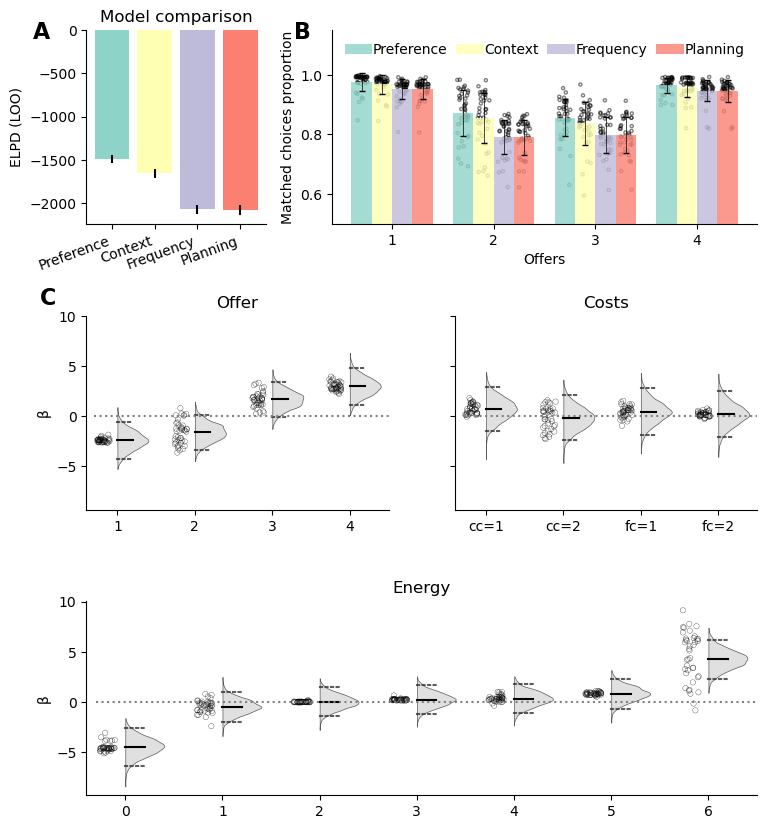

In [96]:
#| label: fig-choicemdl
#| fig-cap: "Results of participants choice behaviour models. (A) Result of the model comparison, displaying the expected log pointwise predictive density (ELPD) 
#| associated with each model (closer to 0 indicate better fit). (B) Observed and fitted probability of accepting the offer separately for each offer by each of the models.
#| The single dots represent the average acceptance probability for each subject. (C) Fitted preference parameters of the preference model. Top left figure 
#| depicts the parameters associated with offer parameters, top right associated with each cost, bottom with each energy level. The bar in the middle of each distribution
#| is the median and the dotted lines represent the 2.5 and 97.5% quantiles. The dots represent the mean of the parameter estimated for each participant"
fig, ax = plt.subplot_mosaic("AABBBB;CCCDDD;EEEEEE", figsize=[A4_inches[0], 0.75*A4_inches[1]])
# fig, ax = plt.subplots(2, 2, figsize=(12, 12))
cmap = matplotlib.colormaps.get_cmap('Set3')
# ================================================
# fig-2A: model comparison:
# elpd_loo bar plot with error bar
ax["A"].bar(    
    [s.split(' ')[0] for s in model_comparison.index],
    model_comparison["elpd_loo"],
    yerr=model_comparison["se"],
    color=cmap(range(len(model_comparison)))
)
# Decoration
ax["A"].set_ylabel("ELPD (LOO)")
ax["A"].set_title("Model comparison")
ax["A"].set_xticklabels(ax["A"].get_xticklabels(), 
                        rotation=20, ha='right')
ax["A"].spines[['right', 'top']].set_visible(False)
ax["A"].text(-0.2, 1.05, "A", transform=ax["A"].transAxes, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )

# ================================================
# fig-2B: Observed vs. fitted data of each model:
# Plot the true data against predicted values from each model:
pos = [1, 2, 3, 4, 6, 7, 8, 9, 11, 12, 13, 14, 16, 17, 18, 19]
cmap = matplotlib.colormaps.get_cmap('Set3')
ctr = 0
cols = [f"Match_{model_name.lower()}" for model_name in traces.keys()]
lbls = [s.split(' ')[0] for s in traces.keys()]
for o in [1, 2, 3, 4]:
    for col_i, col in enumerate(cols):
        # Group the data per participants:
        val = beh_data[beh_data['reward'] == o].groupby(['vpn'])[col].mean().reset_index()[col].to_numpy() 
        # Plot average across participants
        if o == 1:
            label = lbls[col_i]
        else:
            label = None

        # Plot single participants values:
        ax["B"].scatter(np.random.uniform(0.2, 0.8, len(val)) + pos[ctr]-1/2, val, s=5, marker="o", color='k', facecolors='none', alpha=0.5)
        ax["B"].bar(pos[ctr], np.mean(val), 
                    width=1, 
                    color=cmap(col_i), 
                    label=label,
                    alpha=0.8)
        # Add error bars:
        ax["B"].errorbar(pos[ctr], np.mean(val), yerr=np.std(val), color='k', capsize=2, linewidth=0.5)
        
        ctr += 1
ax["B"].set_xticks([2.5, 7.5, 12.5, 17.5])
ax["B"].set_xticklabels([1, 2, 3, 4])
ax["B"].set_ylim([0.5, 1.15])
ax["B"].set_xlabel("Offers")
ax["B"].set_ylabel("Matched choices proportion")
ax["B"].spines[['right', 'top']].set_visible(False)
ax["B"].text(-0.05, 1.05, "B", transform=ax["B"].transAxes, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )
ax["B"].legend(frameon=False, mode="expand", loc="upper left", ncol=4, handletextpad=0.05) # , bbox_to_anchor=(0., 0.9));

# ================================================
# fig-2C: Plot the preferences parameters of the preference model:
ylim = []
violinparts = []
width = 0.8
# Add ax label:
ax["C"].text(-0.1, 1.15, "C", transform=ax["C"].transAxes, 
                fontsize=16, fontweight='bold', va='top', ha='right'
                ) 

# ===========================
# Plot offer parameters:
data = []
for var in ["B_is_1", "B_is_2", "B_is_3", "B_is_4"]:
    vals = traces['Preference'].posterior["beta_pref"].sel(coef_pref=var).values.flatten()
    data.append(vals)
prts = ax["C"].violinplot(data, positions=range(len(data)), widths=width,
                    showmeans=False, showmedians=True,
                    showextrema=False, side="high", 
                    quantiles=[[0.025, 0.975]]*len(data));
violinparts.append(prts)
ax["C"].set_xticks(range(len(data)))
ax["C"].set_xticklabels([1, 2, 3, 4])
ax["C"].set_ylabel("β")
ax["C"].hlines(0, -0.3, 3.5, color='gray', linestyles=':')
ax["C"].set_xlim([-0.4, 3.5])
ax["C"].spines[['right', 'top']].set_visible(False)
ax["C"].set_title("Offer")

# Plot the single participants fit:
data = []
positions = []
for i, var in enumerate(["B_is_1", "B_is_2", "B_is_3", "B_is_4"]):
    vals = traces['Preference'].posterior["beta_pref_sub"].sel(coef_pref=var).mean(dim=["chain", "draw"]).values
    data.append(vals)
    positions.append(np.random.uniform(low=i - (width*1/3), high=i-width*1/8, size=len(vals)))
ax["C"].scatter(positions, data, s=15, c='None', edgecolors="k", linewidth=0.2)
ylim.append(ax["C"].get_ylim())

# ===========================
# Plot Costs parameters:
data = []
for var in ["B_is_lc", "B_is_hc", "B_is_lfc", "B_is_hfc"]:
    vals = traces['Preference'].posterior["beta_pref"].sel(coef_pref=var).values.flatten()
    data.append(vals)
prts = ax["D"].violinplot(data, positions=range(len(data)), widths=width,
                    showmeans=False, showmedians=True,
                    showextrema=False, side="high",
                    quantiles=[[0.025, 0.975]]*len(data));
violinparts.append(prts)
ax["D"].set_xticks(range(len(data)))
ax["D"].set_xticklabels(['cc=1', 'cc=2', 'fc=1', 'fc=2'])
ax["D"].set_yticklabels([])
ax["D"].hlines(0, -0.3, 3.5, color='gray', linestyles=':')
ax["D"].set_xlim([-0.4, 3.5])
ax["D"].spines[['right', 'top']].set_visible(False)
ax["D"].set_title("Costs")

# Plot the single participants fit:
data = []
positions = []
for i, var in enumerate(["B_is_lc", "B_is_hc", "B_is_lfc", "B_is_hfc"]):
    vals = traces['Preference'].posterior["beta_pref_sub"].sel(coef_pref=var).mean(dim=["chain", "draw"]).values
    data.append(vals)
    positions.append(np.random.uniform(low=i - (width*1/3), high=i-width*1/8, size=len(vals)))
ax["D"].scatter(positions, data, s=15, c='None', edgecolors="k", linewidth=0.2)
ylim.append(ax["D"].get_ylim())

# ===========================
# Plot energy parameters:
data = []
for var in ["B_e_is_0", "B_e_is_1", "B_e_is_2", "B_e_is_3", 
            "B_e_is_4", "B_e_is_5", "B_e_is_6"]:
    vals = traces['Preference'].posterior["beta_pref"].sel(coef_pref=var).values.flatten()
    data.append(vals)
prts = ax["E"].violinplot(data, positions=range(len(data)), widths=width, 
                     showmeans=False, showmedians=True,
                     showextrema=False, side="high",
                     quantiles=[[0.025, 0.975]]*len(data));
violinparts.append(prts)
ax["E"].set_xticks(range(len(data)))
ax["E"].set_xticklabels([0, 1, 2, 3, 4, 5, 6])
ax["E"].hlines(0, -0.3, 6.5, color='gray', linestyles=':')
ax["E"].set_xlim([-0.4, 6.5])
ax["E"].set_title('Energy')
ax["E"].spines[['right', 'top']].set_visible(False)
ax["E"].set_ylabel("β")

# Plot the single participants fit:
data = []
positions = []
for i, var in enumerate(["B_e_is_0", "B_e_is_1", "B_e_is_2", "B_e_is_3", 
                         "B_e_is_4", "B_e_is_5", "B_e_is_6"]):
    vals = traces['Preference'].posterior["beta_pref_sub"].sel(coef_pref=var).mean(dim=["chain", "draw"]).values
    data.append(vals)
    positions.append(np.random.uniform(low=i - (width*1/3), high=i-width*1/8, size=len(vals)))
ax["E"].scatter(positions, data, s=15, c='None', edgecolors="k", linewidth=0.2)

# ax_energy.set_title("Energy parameters")
ylim.append(ax["E"].get_ylim())

ax["C"].set_ylim([np.min(ylim), np.max(ylim)])
ax["D"].set_ylim([np.min(ylim), np.max(ylim)])
ax["E"].set_ylim([np.min(ylim), np.max(ylim)])

# Adjust the aspect of the violins
for prts in violinparts:
    for pc in prts['bodies']:
        pc.set_facecolor(cmap(8))
        pc.set_edgecolor([0.2, 0.2, 0.2, 0.8])
        pc.set_linewidth(0.5)
        pc.set_alpha(0.8)
    prts['cquantiles'].set_color([0.2, 0.2, 0.2])
    prts['cquantiles'].set_linestyle(":")
    prts['cquantiles'].set_alpha(0.8)
    prts['cmedians'].set_color("k")

plt.tight_layout();


In [97]:
#| label: tbl-pref_model_param
#| tbl-cap: "Summary of the parameters of the preference model. The table displays the mean and 95% highest density interval (HDI) for the population level parameters
#| associated with the planning values, the preference regressors and their interaction."
# Print the table as a markdown:
from IPython.display import Markdown, display
stats_summary = az.summary(traces['Preference'], var_names=["beta_planning", "beta_pref", "beta_interaction"], hdi_prob=0.95)
# Creat the row names:
row_names = ["$\\beta_{plan}$", 
             "$\\beta_{O=1}$", "$\\beta_{O=2}$", "$\\beta_{O=3}$", "$\\beta_{O=4}$", 
             "$\\beta_{CC=1}$", "$\\beta_{CC=2}$", "$\\beta_{FC=1}$", "$\\beta_{FC=1}$", 
             "$\\beta_{E=0}$", "$\\beta_{E=1}$", "$\\beta_{E=2}$", "$\\beta_{E=3}$", "$\\beta_{E=4}$", "$\\beta_{E=5}$", "$\\beta_{E=6}$", 
             "$\\beta_{interaction}$"]
stats_summary.index = row_names
display(Markdown(stats_summary[[ "mean", "sd", "hdi_2.5%", "hdi_97.5%" ]].to_markdown()))

|                       |   mean |    sd |   hdi_2.5% |   hdi_97.5% |
|:----------------------|-------:|------:|-----------:|------------:|
| $\beta_{plan}$        |  2.095 | 0.243 |      1.629 |       2.582 |
| $\beta_{O=1}$         | -2.395 | 0.958 |     -4.361 |      -0.605 |
| $\beta_{O=2}$         | -1.613 | 0.935 |     -3.405 |       0.178 |
| $\beta_{O=3}$         |  1.662 | 0.921 |     -0.152 |       3.405 |
| $\beta_{O=4}$         |  2.968 | 0.96  |      1.235 |       4.975 |
| $\beta_{CC=1}$        |  0.733 | 1.146 |     -1.549 |       2.81  |
| $\beta_{CC=2}$        | -0.181 | 1.146 |     -2.402 |       2.022 |
| $\beta_{FC=1}$        |  0.443 | 1.165 |     -1.882 |       2.77  |
| $\beta_{FC=1}$        |  0.2   | 1.166 |     -2.045 |       2.609 |
| $\beta_{E=0}$         | -4.472 | 0.952 |     -6.255 |      -2.558 |
| $\beta_{E=1}$         | -0.467 | 0.777 |     -1.95  |       1.036 |
| $\beta_{E=2}$         |  0.002 | 0.739 |     -1.452 |       1.419 |
| $\beta_{E=3}$         |  0.228 | 0.742 |     -1.193 |       1.697 |
| $\beta_{E=4}$         |  0.331 | 0.749 |     -1.084 |       1.833 |
| $\beta_{E=5}$         |  0.823 | 0.762 |     -0.652 |       2.321 |
| $\beta_{E=6}$         |  4.234 | 0.968 |      2.209 |       6.021 |
| $\beta_{interaction}$ |  1.706 | 0.717 |      0.271 |       3.102 |

In [98]:
# Calculate the interaction confidence intervals:
mu_interaction = traces['Preference'].posterior["beta_interaction"].values.flatten().mean()
ci_interaction = az.hdi(traces['Preference'].posterior["beta_interaction"].values)[0]

We next asked whether the influence of planning depends on how informative participants’ preferences are. If preferences and planning jointly guide choice, then choices should be dominated by whichever source provides the clearer signal on a given trial. Consistent with this idea, our model revealed a positive modulatory effect of preferences entropy on planning ($\beta_{modulation}$=`{python} f"{mu_interaction:.2f}"`, CI=[`{python} f"{ci_interaction[0]:.2f}, {ci_interaction[1]:.2f}"`], see @fig-pref-planning-interaction A). This positive effect implies that the more informative source of information exerts the stronger influence on participants' choices. When preferences are strong and DV are close to 0, participants follow their preferences. Conversly, when preferences are weak and DV strongly favour one action, choices follow planning derived values. 

This effect can be seen when the sign of preferences and DV are opposed (one suggests accepting and the other rejecting or vice versa), as participants choice should either reflect preference or planning depending on their relative strength. @fig-pref-planning-interaction A shows participants responses as a function of preferences and DV, with emphasizes on the off diagonal quadrants (top left and bottom right where the sign of DV and preferences are opposed) by color coding accept and rejected trials (green triangles for accepting, yellow hexagons for rejecting). The background colors indicate the fitted probability of accepting an offer as a function of preferences and DV. In the top left quadrant, participants follow their preferences (i.e. accept) when DV are low relative to preferences, hence the green markers cluster close to DV equal to 0, while participants reject (i.e. follow DV) when DV are strong relative to preferences, hence the yellow marker cluster towards more negative DV. The contour line in the background reflect this modulatory effect, as the probability of rejecting an offer for a given DV decreases as preferneces score increases in the top left corner. Similarly, in the bottom right corner, the probability of accepting (i.e. following DV) an offer for a given DV decreases as preferences grows more negative. The effect of preferences on participants' responses can further be seen in @fig-pref-planning-interaction B, where responses were binned as a function of DV, separately for states where preferences are positive (top row) and negative (bottom row). We can see that for a given DV, the probability of accepting is systematically increased when preferences are positive compared to when preferences are negative. 

Notably, both figures highlight that there are fewer trials in which DV are positive while preferences are negative (bottom right quadrant in @fig-pref-planning-interaction A). Furthermore, there are no trials in which preferences are strongly negative when DV are clearly positive (bottom right quadrant), while there are cases in which preferences are strongly positive while DV are strongly negative (top left). This indicates that bias towards rejecting an offer tends to be aligned with the DV, while participants sometimes show bias towards accepting when planning would suggest otherwise. This asymetry reflects the structure of our task. Strongly positive preference with strongly negative DV occur in trials where offer is high and energy is low, such that planning suggests to forgo a large offer to ensure future offers can be accepted, while participants preference for large offers outweights the weights associated with remaining factors. In the mirror case, where offer is low and energy is high, planning suggests rejecting the offer because sparing energy is preferrable, and so do preferences, as the negative weight associated with low offer is rarely outweighted by the positive bias associated with high energy states. 

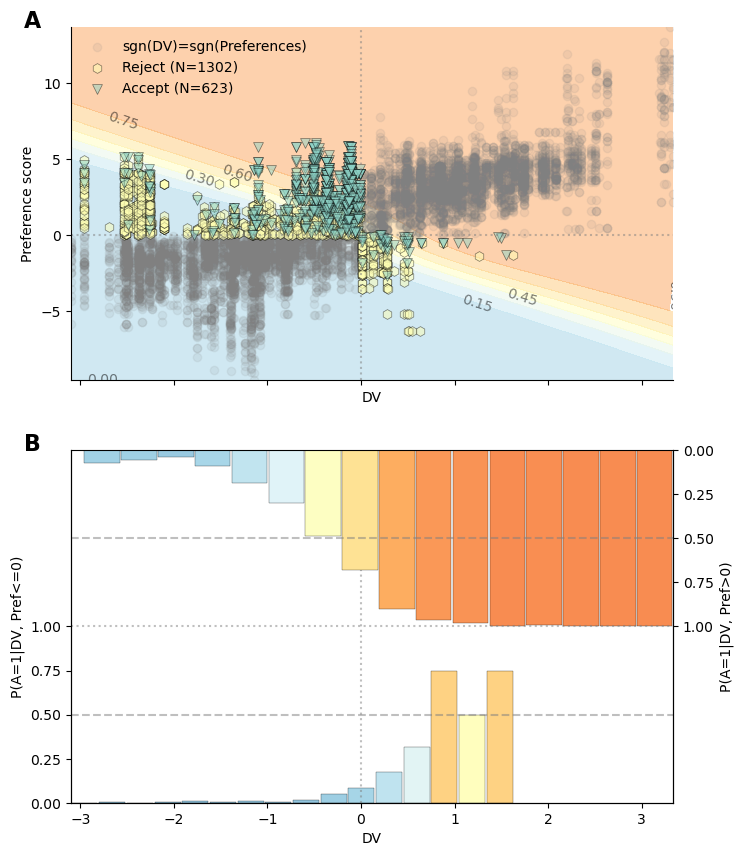

In [99]:
#| label: fig-pref-planning-interaction
#| fig-cap: "Interaction between preferences and DV. (A) Shows participants responses as a function of decision values and preference scores. 
#| On the off diagonal quadrant (top left and bottom right), the dot color indicate whether participants accepted the reward (green triangles) or rejected 
#| the reward (yellow octogons). The numbers in the legend refer to the number of trials. Background color indicate predicted 
#| probability of accepting the offer under the preference model, contour line correspond to the labelled probability. (B) Shows the probabiltiy of accepting
#| an offer (y axis) binned per decision values (x axis), separately for trials in which preference score is positive (top bars pointing down) 
#| or negative (bottom bars pointing up). In the same way as (A), the top left and bottom right quadrant show trials in which preferences and DV are opposed, 
#| while bottom left and top right quandrant show trials where preferences and DV are aligned. Bars colors reflects the probability of accepting to 
#| vizualize the influence of preferences sign under matched DV.  "
fig, ax = plt.subplot_mosaic("A;B", figsize=[A4_inches[0], 0.9*A4_inches[1]], sharex=True)
cmap = matplotlib.colormaps.get_cmap('Set3')

# ================================================================
# fig-3A: Plot the interaction between preferences and decision values:
x1_grid, x2_grid, x_grid = make_grid(beh_data['dv'].min(), beh_data['dv'].max(), beh_data['preference_score'].min(), beh_data['preference_score'].max())

# =================================
# Plot the predicted response probability in the background:
cmap_background = truncate_colormap(plt.get_cmap("RdYlBu_r"),  min_val=0.25, max_val=0.75)
# Create grid:
grid_df = pd.DataFrame(x_grid, columns=["dv", "pref"])
# Simulate responses across the grid:
grid_df["p"] = predict_responses(grid_df["dv"], grid_df["pref"], traces["Preference"])
p_grid = grid_df.pivot(index="pref", columns="dv", values="p").to_numpy()
# Plot contours:
cs = ax["A"].contourf(x1_grid, x2_grid, p_grid, alpha=0.5, cmap=cmap_background)
ax["A"].clabel(cs, fontsize=10, colors='k')
ax["A"].axvline(0, linestyle=":", color="grey", alpha=0.5)
ax["A"].axhline(0, linestyle=":", color="grey", alpha=0.5)

# =================================
# Plot responses as a function of DV and pref:
# Get trials where pref and DV are opposed:
# mismatch accept
mismatch_accept = beh_data[(np.sign(beh_data['dv']) != np.sign(beh_data['preference_score'])) & (beh_data['response'] == 1)]
# mismatch reject
mismatch_reject= beh_data[(np.sign(beh_data['dv']) != np.sign(beh_data['preference_score'])) & (beh_data['response'] == 0)]
# Get the rest:
matched = beh_data[(np.sign(beh_data['dv']) == np.sign(beh_data['preference_score']))]
# Plot each mismatch
ax["A"].scatter(matched['dv'], matched['preference_score'], 
                color="grey", marker='o', alpha=0.1,
                label=f'sgn(DV)=sgn(Preferences)')
ax["A"].scatter(mismatch_reject['dv'], mismatch_reject['preference_score'], 
                color=cmap(1), edgecolors='black', linewidths=0.5, s=50,
                label=f'Reject (N={mismatch_reject.shape[0]})', marker='h', alpha=0.5)
ax["A"].scatter(mismatch_accept['dv'], mismatch_accept['preference_score'], 
                color=cmap(0), edgecolors='black', linewidths=0.5, s=50,
                label=f'Accept (N={mismatch_accept.shape[0]})', marker='v', alpha=0.5)
# Decoration:
ax["A"].set_xlabel("DV")
ax["A"].set_ylabel("Preference score")
ax["A"].text(-0.05, 1.05, "A", transform=ax["A"].transAxes, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )
ax["A"].spines[['right', 'top']].set_visible(False)
ax["A"].legend(frameon=False)
xlim = ax["A"].get_xlim()

# ================================================================
# fig-3B: Response probability binned per decision value
# Separate between positive and negative preferences, to highlight that the 
# preferences do make a difference:
pref_positive = beh_data[beh_data['preference_score'] > 0]
pref_negative = beh_data[beh_data['preference_score'] <= 0]

# Plot binned resp for dv <=0:
my_cmap = truncate_colormap(plt.get_cmap("RdYlBu_r"),  min_val=0.25, max_val=0.75)
rescale = lambda y: (y - np.min(y)) / (np.max(y) - np.min(y))

# Bin the data:
bins = pd.cut(pref_negative['dv'], bins=16)
pa_pref_negative = pref_negative.groupby(bins)['response'].mean()
bins = pd.cut(pref_positive['dv'], bins=16)
pa_pref_positive = pref_positive.groupby(bins)['response'].mean()
# Get the mins and maxs to normalize the color bar:
min_pa, max_pa = np.min([pa_pref_negative.min(), pa_pref_positive.min()]), np.max([pa_pref_negative.max(), pa_pref_positive.max()])

# Create the normalized color bar:
my_cmap = truncate_colormap(plt.get_cmap("RdYlBu_r"),  min_val=0.25, max_val=0.75)
rescale = lambda y: (y - min_pa) / (max_pa - min_pa)

# =================================
# Plot binned resp for dv <=0:
position = pd.IntervalIndex(pa_pref_negative.index).mid
ax["B"].bar(   
    position.to_numpy(), 
    pa_pref_negative.to_numpy(),
    facecolor=my_cmap(rescale(pa_pref_negative.to_numpy())),
    width=pd.IntervalIndex(pa_pref_negative.index).length[0]-0.02,
    edgecolor='k',
    linewidth=0.2
)
ax["B"].set_ylim([0, 2])
ax["B"].set_yticks([0, 0.25, 0.5, 0.75, 1])
ax["B"].set_xlim(xlim)
ax["B"].set_xlabel("DV")
ax["B"].axvline(0, linestyle=":", color="grey", alpha=0.5)
ax["B"].axhline(0.5, linestyle="--", color="grey", alpha=0.5)
ax["B"].set_ylabel("P(A=1|DV, Pref<=0)")
ax["B"].text(-0.05, 1.05, "B", transform=ax["B"].transAxes, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )
ax["B"].spines[['top']].set_visible(False)

# =================================
# Plot binned resp for dv >0:
ax2 = ax["B"].twinx()
position = pd.IntervalIndex(pa_pref_positive.index).mid
ax2.bar(   
    position.to_numpy(), 
    pa_pref_positive.to_numpy(),
    facecolor=my_cmap(rescale(pa_pref_positive.to_numpy())),
    width=pd.IntervalIndex(pa_pref_positive.index).length[0]-0.02,
    edgecolor='k',
    linewidth=0.2
)
ax2.axhline(1, linestyle=":", color="grey", alpha=0.5)
ax2.set_ylim([0, 2])
ax2.set_yticks([0, 0.25, 0.5, 0.75, 1])
ax2.yaxis.set_inverted(True);
ax2.set_xlim(xlim)
ax2.set_xlabel("DV")
ax2.set_ylabel("P(A=1|DV, Pref>0)")
ax2.axhline(0.5, linestyle="--", color="grey", alpha=0.5);

In [100]:
from scipy.stats import zscore
# Compute correlation between models parameters and return:
# Get the return from each subject:
subjects_returns = []
for sub in beh_data['vpn'].unique():
    subjects_returns.append(beh_data[beh_data['vpn'] == sub]["points"].to_numpy()[-1])
subjects_returns = np.array(subjects_returns)

# Z score participants returns to identify outliers:
zscore_return = zscore(subjects_returns)
min_return_sd = np.abs(min(zscore_return))
outlier_mask = [i for i, _ in enumerate(subjects_returns) if subjects_returns[i] != min(subjects_returns)]

# ==========================================================
# Planning and return:
# Get the corresponding planning beta from the preference model:
planning_betas = np.squeeze(np.mean(traces['Preference'].posterior["beta_planning_sub"], axis=(0, 1)).to_numpy())
# Compute correlation coefficient:
r = pearsonr(planning_betas, subjects_returns)
r_planning, pval_planning = r.statistic, r.pvalue

# Removing the outlier:
r = pearsonr(planning_betas[outlier_mask], subjects_returns[outlier_mask])
r_planning_no_outlier, pval_planning_no_outlier = r.statistic, r.pvalue

# ==========================================================
# Pref entropy & return
# Get the entropy:
beh_data['entropy'] = np.mean(traces['Preference'].posterior["entropy"], axis=(0, 1))
pref_entropy = beh_data.groupby('vpn')['entropy'].mean().reset_index()['entropy'].to_numpy()
# Compute correlation coefficient:
r = pearsonr(pref_entropy, subjects_returns)
r_pref, pval_pref = r.statistic, r.pvalue

# Removing the outlier:
r = pearsonr(pref_entropy[outlier_mask], subjects_returns[outlier_mask])
r_pref_no_outlier, pval_pref_no_outlier = r.statistic, r.pvalue

# ==========================================================
# Interaction & return
# Get the entropy:
interaction_beta = np.squeeze(np.mean(traces['Preference'].posterior["beta_interaction_sub"], axis=(0, 1)).to_numpy())
# Compute correlation coefficient:
r = pearsonr(interaction_beta, subjects_returns)
r_interaction, pval_interaction = r.statistic, r.pvalue

# Removing the outlier:
r = pearsonr(interaction_beta[outlier_mask], subjects_returns[outlier_mask])
r_interaction_no_outlier, pval_interaction_no_outlier = r.statistic, r.pvalue

To further establish the behavioural relevance of the planning parameter, the preference score and the modulatory effect of preferences entropy, we tested whether they are predictive of participants overall performances. As larger $\beta_{planning}$ values indicate stronger reliance on planning, we expected participants with larger $\beta_{planning}$ to obtain higher returns. In contrast to planning, preferences might sometimes not maximize reward, so participants with strong preferences (i.e. low preference entropy) should obtain lower return on average. Finally, larger $\beta_{modulation}$ indicate that participants plan more when their preferences are weak (i.e. preferences entropy is larger), and should accordingly obtain larger returns compared to participants' who do not engage more strongly in planning when their preferences are weak. Accordingly, we predicted that $\beta_{planning}$, preferences entropy and $\beta_{modulation}$ should be positively correlated with return. 

In line with our prediction, we observed a positive correlation between $\beta_{planning}$ and return (r=`{python} f"{r_planning:.2f}"`, p=`{python} f"{pval_planning:.3f}"`, @fig-returns B), showing that participants who rely more on planning get larger return. Furthermore, $\beta_{modulation}$ is strongly and positively correlated with return (r=`{python} f"{r_interaction:.2f}"`, p=`{python} f"{pval_interaction:.3f}"`, @fig-returns C). However, contrary to our prediction, we observed a negative correlation though only marginally significant correlation between preferences entropy and return (r=`{python} f"{r_pref:.2f}"`, p=`{python} f"{pval_pref:.3f}"`, @fig-returns D). Visual inspection of @fig-returns D revealed that the correlation appears to be driven from the subject with very low return (`{python} f"{min_return_sd:.2f}"` standard deviations from population mean). When removing this subject, the correlation between preferences entropy and return is not marginally significant (r=`{python} f"{r_pref_no_outlier:.2f}"`, p=`{python} f"{pval_pref_no_outlier:.3f}"`), while it remains strongly significant for planning (r=`{python} f"{r_planning_no_outlier:.2f}"`, p=`{python} f"{pval_planning_no_outlier:.3f}"`) and modulation (r=`{python} f"{r_interaction_no_outlier:.2f}"`, p=`{python} f"{pval_interaction_no_outlier:.3f}"`) when the same subject is removed. 

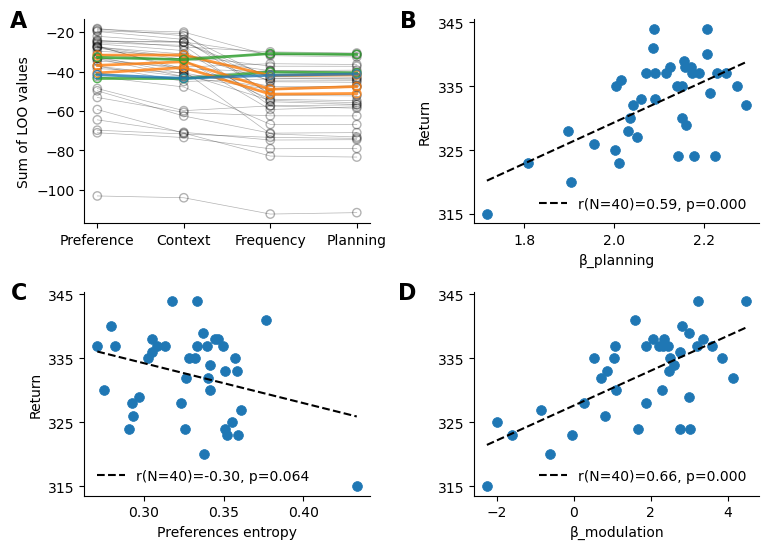

In [118]:
#| label: fig-returns
#| fig-cap: "Single participants fit and performances (A) Model fit for each participant. (B) Correlation between participants return and the fitted 
#| $\\beta_{planning}$ parameter. Each dot represent a single participant, the line is a correlation fitted using optimal least square, legend indicates pearson
#| correlation alongside p value. (C) Correlation between participants performances and the average preference entropy. Same convention as (B). (C) Correlation 
#| between participants performances and $\\beta_{modulation}$. Same convention as (B)
#| and model, color coded by model of best fit."
fig, ax = plt.subplot_mosaic("AB;CD", figsize=[A4_inches[0], 0.5*A4_inches[1]])
# ================================================
# Single participant model fit:
ctr_mdl = {mdl: 0 for mdl in loo_results.keys()}
cmap = ["k", "tab:orange", "tab:green", "tab:blue"]
for sub in loos_sub['vpn']:
    # Extract the data from this participant:
    sub_loo = loos_sub[loos_sub["vpn"] == sub][loo_results.keys()]
    # Extract the winning model:
    winning = sub_loo.idxmax(axis=1).values[0]
    if ctr_mdl[winning] == 0:
        lbl = winning.split(' ')[0]
    else:
        lbl = None
    # Determine the color accordingly:
    c = cmap[list(loo_results.keys()).index(winning)]
    if winning == "Preference":
        alpha = 0.3
        zorder = 0
        linewidth=0.5
    else:
        alpha = 0.8
        zorder = 1000
        linewidth = 2
    ax["A"].scatter(range(len(traces)), np.squeeze(sub_loo.to_numpy()), color=c, alpha=alpha, facecolors='none', zorder=zorder)
    ax["A"].plot(range(len(traces)), np.squeeze(sub_loo.to_numpy()), color=c, label=lbl, alpha=alpha, zorder=zorder, linewidth=linewidth)
    ctr_mdl[winning] += 1
ax["A"].set_xticks(range(len(traces)))
ax["A"].set_xticklabels([s.split(' ')[0] for s in traces.keys()]) # , ha='right')
ax["A"].set_ylabel("Sum of LOO values")
ax["A"].spines[['right', 'top']].set_visible(False)
# ax["A"].legend(frameon=False, bbox_to_anchor=(0.95, 0.9))
ax["A"].text(-0.2, 1.05, "A", transform=ax["A"].transAxes, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )

# ================================================================
# fig-3B: Plot the correlation between total return and the planning weight:
# Sort according to beta strength:
order = np.argsort(planning_betas)
# Plot correlation between the two:
coef = np.polyfit(np.squeeze(planning_betas[order]), subjects_returns[order], 1)
poly1d_fn = np.poly1d(coef)
ax["B"].scatter(np.squeeze(planning_betas[order]), subjects_returns[order],linewidths=0.5, s=50)
ax["B"].plot(np.squeeze(planning_betas[order]), poly1d_fn(np.squeeze(planning_betas[order])), 
             color='k', linestyle='--', label=f'r(N={len(subjects_returns)})={r_planning:.2f}, p={pval_planning:.3f}')
ax["B"].set_xlabel("β_planning")
ax["B"].set_ylabel("Return")
ax["B"].set_yticks([315, 325, 335, 345])
ax["B"].set_yticklabels([315, 325, 335, 345])
ax["B"].text(-0.2, 1.05, "B", transform=ax["B"].transAxes, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )
ax["B"].spines[['right', 'top']].set_visible(False)
ax["B"].legend(frameon=False, prop={'size': 10})

# ================================================================
# fig-3C: Plot the correlation between total return and the preferences entropy:
order = np.argsort(pref_entropy)
# Plot correlation between the two:
coef = np.polyfit(np.squeeze(pref_entropy[order]), subjects_returns[order], 1)
poly1d_fn = np.poly1d(coef)
ax["C"].scatter(pref_entropy[order], subjects_returns[order], linewidths=0.5, s=50)
ax["C"].plot(pref_entropy[order], poly1d_fn(pref_entropy[order]), color='k', linestyle='--', 
             label=f'r(N={len(subjects_returns)})={r_pref:.2f}, p={pval_pref:.3f}')
ax["C"].set_xlabel("Preferences entropy")
ax["C"].set_ylabel("Return")
ax["C"].set_yticks([315, 325, 335, 345])
ax["C"].set_yticklabels([315, 325, 335, 345])
ax["C"].text(-0.2, 1.05, "C", transform=ax["C"].transAxes, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )
ax["C"].spines[['right', 'top']].set_visible(False)
ax["C"].legend(frameon=False, prop={'size': 10})

# ================================================================
# fig-3D: Plot the correlation between total return and the preferences entropy:
order = np.argsort(interaction_beta)
# Plot correlation between the two:
coef = np.polyfit(np.squeeze(interaction_beta[order]), subjects_returns[order], 1)
poly1d_fn = np.poly1d(coef)
ax["D"].scatter(interaction_beta[order], subjects_returns[order], linewidths=0.5, s=50)
ax["D"].plot(interaction_beta[order], poly1d_fn(interaction_beta[order]), color='k', linestyle='--', 
             label=f'r(N={len(subjects_returns)})={r_interaction:.2f}, p={pval_interaction:.3f}')
ax["D"].set_xlabel("β_modulation")
ax["D"].set_yticks([315, 325, 335, 345])
ax["D"].set_yticklabels([315, 325, 335, 345])
ax["D"].text(-0.2, 1.05, "D", transform=ax["D"].transAxes, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )
ax["D"].spines[['right', 'top']].set_visible(False)
ax["D"].legend(frameon=False, prop={'size': 10})
plt.tight_layout();

### Experimental factors relevance

Our results indicate that participants choices are shaped by two sources of information: planning-derived values and task-structured preferences. These preferences are not a single global bias. Instead, participants appear to assign preferences to different features of the task, such as the offer, the current cost context, and upcoming transitions, and combine these feature-specific preferences into an overall preference for each action in a given state. Importantly, not  all features of the task are weighted equally. @fig-choicemdl C shows that the parameters associated with offers and energy weight strongly in participants preferences compared to costs (both current and future). To identify which aspects of task structure participants use to guide their choices, we compared models in which individual preference components were removed one at a time. This effectively tests how decision making changes when participants are assumed to ignore one specific sources of task information, such as offer value, action costs, or future transitions.

@fig-task-features A displays the difference in fit between the full preference model against models in which the preferences related to each experimental factor was removed, larger values indicate that the factor account for a more important proportion of the full model's fit. These results indicate that energy followed by offer have a much larger impact on participants final responses, whereas costs related preferences have a small impact on the overall fit. 

In [102]:
# Full model:
traces_reduced = {"Preference": traces["Preference"]}

if os.path.exists("./data/bids/limited_energy/derivatives/control_models/preferences_model_no_offer_trace.nc"):
    idata = az.from_netcdf("./data/bids/limited_energy/derivatives/control_models/preferences_model_no_offer_trace.nc")
    traces_reduced['Offer'] = idata
else:
    preference_columns = [
        'is_lc', 'is_hc', 
        'is_lfc', 'is_hfc',
        'e_is_0', 'e_is_1', 'e_is_2', 'e_is_3', 'e_is_4', 'e_is_5', 'e_is_6'
    ]
    idata = preference_model(beh_data['response'],  # Subjects responses
                                np.squeeze(beh_data[['dv']].to_numpy()),  # Optimal decision values
                                beh_data[preference_columns],  # Preferences regressors
                                subj_idx_raw, subj_labels)
    # Add the idata to the rest:
    traces_reduced['Offer'] = idata
    # Save the trace to file:
    az.to_netcdf(traces_reduced['Offer'], "./data/bids/limited_energy/derivatives/control_models/preferences_model_no_offer_trace.nc")

# Fit the model without the offer related preferences:
if os.path.exists("./data/bids/limited_energy/derivatives/control_models/preferences_model_no_costs_trace.nc"):
    idata = az.from_netcdf("./data/bids/limited_energy/derivatives/control_models/preferences_model_no_costs_trace.nc")
    traces_reduced['CC'] = idata
else:
    # Fit the model without the costs related preferences:
    preference_columns = [
        'is_1', 'is_2', 'is_3', 'is_4', 
        'is_lfc', 'is_hfc',
        'e_is_0', 'e_is_1', 'e_is_2', 'e_is_3', 'e_is_4', 'e_is_5', 'e_is_6'
    ]
    idata = preference_model(beh_data['response'],  # Subjects responses
                                np.squeeze(beh_data[['dv']].to_numpy()),  # Optimal decision values
                                beh_data[preference_columns],  # Preferences regressors
                                subj_idx_raw, subj_labels)
    # Add the idata to the rest:
    traces_reduced['CC'] = idata
    # Save the trace to file:
    az.to_netcdf(traces_reduced['CC'], "./data/bids/limited_energy/derivatives/control_models/preferences_model_no_costs_trace.nc")

# Fit the model without the offer related preferences:
if os.path.exists("./data/bids/limited_energy/derivatives/control_models/preferences_model_no_fc_trace.nc"):
    idata = az.from_netcdf("./data/bids/limited_energy/derivatives/control_models/preferences_model_no_fc_trace.nc")
    traces_reduced['FC'] = idata
else:
    # Fit the model without the transitions related preferences:
    preference_columns = [
        'is_1', 'is_2', 'is_3', 'is_4', 
        'is_lc', 'is_hc', 
        'e_is_0', 'e_is_1', 'e_is_2', 'e_is_3', 'e_is_4', 'e_is_5', 'e_is_6'
    ]
    idata = preference_model(beh_data['response'],  # Subjects responses
                                np.squeeze(beh_data[['dv']].to_numpy()),  # Optimal decision values
                                beh_data[preference_columns],  # Preferences regressors
                                subj_idx_raw, subj_labels)
    # Add the idata to the rest:
    traces_reduced['FC'] = idata
    # Save the trace to file:
    az.to_netcdf(traces_reduced['FC'], "./data/bids/limited_energy/derivatives/control_models/preferences_model_no_fc_trace.nc")

# Fit the model without the offer related preferences:
if os.path.exists("./data/bids/limited_energy/derivatives/control_models/preferences_model_no_energy_trace.nc"):
    idata = az.from_netcdf("./data/bids/limited_energy/derivatives/control_models/preferences_model_no_energy_trace.nc")
    traces_reduced['Energy'] = idata
else:
    # Fit the model without the energy related preferences:
    preference_columns = [
        'is_1', 'is_2', 'is_3', 'is_4', 
        'is_lc', 'is_hc', 
        'is_lfc', 'is_hfc',
    ]
    idata = preference_model(beh_data['response'],  # Subjects responses
                                np.squeeze(beh_data[['dv']].to_numpy()),  # Optimal decision values
                                beh_data[preference_columns],  # Preferences regressors
                                subj_idx_raw, subj_labels)
    # Add the idata to the rest:
    traces_reduced['Energy'] = idata
    # Save the trace to file:
    az.to_netcdf(traces_reduced['Energy'], "./data/bids/limited_energy/derivatives/control_models/preferences_model_no_energy_trace.nc")

# Compare against the full model:
model_comparison = az.compare(traces_reduced)

In [103]:
# Compute the reduced MDPs:
return_reduced = {
    "Offer": None,
    "Energy": None,
    "CC": None,
    "FC": None,
}
max_return = task_mdp.expected_return(task_mdp.greedy_policy(Q_full), initial_energy=3)

# ==================================================================
# Offer reduced MDP:
# Get all single states without the offers:
inds = [0, 2, 3, 4]
states_no_offers = list(set(tuple([state[i] for i in inds]) for state in task_mdp.states))
# Create state classes, i.e. list of states groups that share everything but the offer:
states_classes = []
for state_r in states_no_offers:
    class_ = []
    for state in task_mdp.states:
        if tuple(state[i] for i in inds) == state_r:
            class_.append(state)
    states_classes.append(class_)
# Reduce the MDP accordingly:
statesR, tpR, rR, class_of_state = avg_reduce_mdp(states_classes, task_mdp.tp, task_mdp.r, task_mdp.s2i)
# Create abstract MDP:
V_R, Q_R = MDP(statesR, tpR, rR, gamma).backward_induction()
# Project back to ground space:
_, Q = abstract2ground_value(class_of_state, V_R, Q_R)
# Compute the expected return:
return_reduced["Offer"] = 1 - (task_mdp.expected_return(task_mdp.greedy_policy(Q), initial_energy=3) / max_return)

# ==================================================================
# Energy reduced MDP:
# Get all single states without the Energy:
inds = [1, 2, 3, 4]
states_no_energy =  list(set(tuple([state[i] for i in inds]) for state in task_mdp.states))
# Create state classes, i.e. list of states groups that share everything but the offer:
states_classes = []
for state_r in states_no_energy:
    class_ = []
    for state in task_mdp.states:
        if tuple(state[i] for i in inds) == state_r:
            class_.append(state)
    states_classes.append(class_)
# Reduce the MDP accordingly:
statesR, tpR, rR, class_of_state = avg_reduce_mdp(states_classes, task_mdp.tp, task_mdp.r, task_mdp.s2i)
# Create abstract MDP:
V_R, Q_R = MDP(statesR, tpR, rR, gamma).backward_induction()
# Project back to ground space:
_, Q = abstract2ground_value(class_of_state, V_R, Q_R)
# Compute the expected return:
return_reduced["Energy"] = 1 - (task_mdp.expected_return(task_mdp.greedy_policy(Q), initial_energy=3) / max_return)

# ==================================================================
# CC reduced MDP:
# Get all single states without the offers:
inds = [0, 1, 3, 4]
states_no_cc=  list(set(tuple([state[i] for i in inds]) for state in task_mdp.states))
# Create state classes, i.e. list of states groups that share everything but the offer:
states_classes = []
for state_r in states_no_cc:
    class_ = []
    for state in task_mdp.states:
        if tuple(state[i] for i in inds) == state_r:
            class_.append(state)
    states_classes.append(class_)
# Reduce the MDP accordingly:
statesR, tpR, rR, class_of_state = avg_reduce_mdp(states_classes, task_mdp.tp, task_mdp.r, task_mdp.s2i)
# Create abstract MDP:
V_R, Q_R = MDP(statesR, tpR, rR, gamma).backward_induction()
# Project back to ground space:
_, Q = abstract2ground_value(class_of_state, V_R, Q_R)
# Compute the expected return:O
return_reduced["CC"] = 1 - (task_mdp.expected_return(task_mdp.greedy_policy(Q), initial_energy=3) / max_return)

# ==================================================================
# FC reduced MDP:
# Get all single states without the offers:
inds = [0, 1, 2, 4]
states_no_fc =  list(set(tuple([state[i] for i in inds]) for state in task_mdp.states))
# Create state classes, i.e. list of states groups that share everything but the offer:
states_classes = []
for state_r in states_no_fc:
    class_ = []
    for state in task_mdp.states:
        if tuple(state[i] for i in inds) == state_r:
            class_.append(state)
    states_classes.append(class_)
# Reduce the MDP accordingly:
statesR, tpR, rR, class_of_state = avg_reduce_mdp(states_classes, task_mdp.tp, task_mdp.r, task_mdp.s2i)
# Create abstract MDP:
V_R, Q_R = MDP(statesR, tpR, rR, gamma).backward_induction()
# Project back to ground space:
_, Q = abstract2ground_value(class_of_state, V_R, Q_R)
# Compute the expected return:
return_reduced["FC"] = 1 - (task_mdp.expected_return(task_mdp.greedy_policy(Q), initial_energy=3) / max_return)

# Sort the dictionary:
return_reduced = {k: v for k, v in sorted(return_reduced.items(), reverse=True, key=lambda item: item[1])}

In [104]:
# Compute expected return from optimal policy and stochastic policy:
n_states = len(task_mdp.states)
returns_stochastic = task_mdp.expected_return(np.array([np.zeros(n_states) + 0.5, np.zeros(n_states) + 0.5]).T)
returns_optimal = task_mdp.expected_return(task_mdp.greedy_policy(Q_full))

# Compute the returns obtained from the preferences only, removing one factor at a time:
returns_pref = {}
mdls = ["full", "CC", "FC", "Energy", "Offer"]
for mdl in mdls:
    # Get all the preferences parameters:
    if mdl == "full":
        pref_params = traces["Preference"].posterior["beta_pref"].mean(dim=["chain", "draw"]).values
    else:
        pref_params = traces_reduced[mdl].posterior["beta_pref"].mean(dim=["chain", "draw"]).values
    if mdl == "full":
        b_offer = pref_params[0:4]
        b_costs =  pref_params[4:6]
        b_fc = pref_params[6:8]
        b_energy = pref_params[8:15]
    if mdl == "CC":
        b_offer = pref_params[0:4]
        b_costs =  np.zeros(2)
        b_fc = pref_params[4:6]
        b_energy = pref_params[6:13]
    if mdl == "FC":
        b_offer = pref_params[0:4]
        b_costs = pref_params[4:6]
        b_fc =  np.zeros(2)
        b_energy = pref_params[6:13]
    if mdl == "Energy":
        b_offer = pref_params[0:4]
        b_costs = pref_params[4:6]
        b_fc = pref_params[6:8]
        b_energy = np.zeros(7)
    if mdl == "Offer":
        b_offer =  np.zeros(4)
        b_costs = pref_params[0:2]
        b_fc = pref_params[2:4]
        b_energy = pref_params[4:11]
    # Project to state space:
    pi = []
    for state in task_mdp.states:
        pi.append(expit(b_offer[state[1]-1] + b_costs[state[2]-1] + b_fc[state[3]-1] + b_energy[state[0]]))
    # Evaluate the policy
    returns_pref[mdl] = 1 - (task_mdp.expected_return(np.array([1-np.array(pi), pi]).T)) / returns_optimal

In [105]:
# Calculate the marginal action distribution associated with each aspect of the task:
pi_optimal = task_mdp.greedy_policy(Q_full)

marginal_action_proba = []

# Loop through each level and each state:
for i, factor in enumerate([task.E, task.O, task.C, task.C]):
    for lvl in factor:
        p_a = []
        for ii, state in enumerate(task_mdp.states):
            if state[i] == lvl:
                p_a.append(pi_optimal[ii])
        # Average:
        marginal_action_proba.append(np.mean(p_a))
# Reorder to match the model:
marginal_action_proba = np.array(marginal_action_proba[7:11] + marginal_action_proba[11:13] + marginal_action_proba[13:15] + marginal_action_proba[0:7])

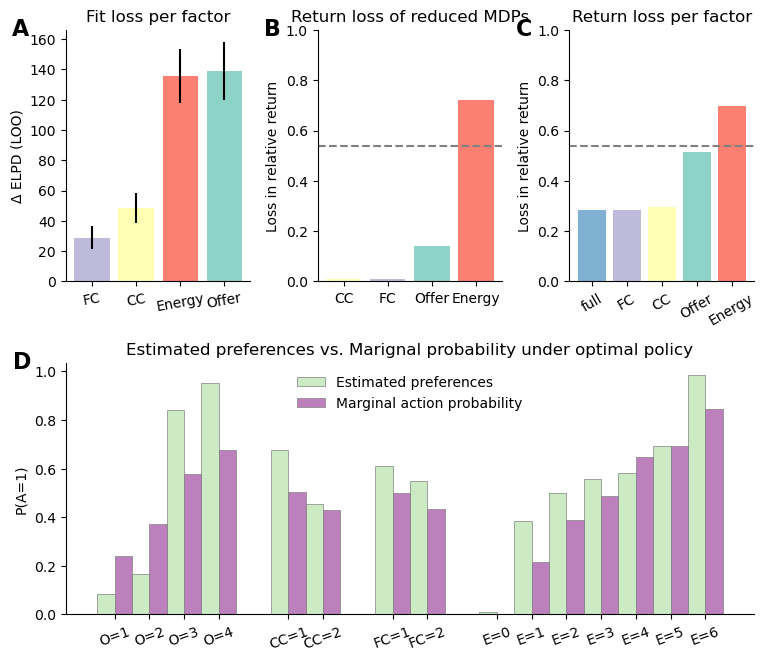

In [ ]:
#| label: fig-task-features
#| fig-cap: "Importance of each parameters in participants response and optimal solution. 
#| (A) Difference in fit
#| between the full preference model and models in which each of the experimental factors were removed from preference estimations. 
#| Values closer to 0 indicate that the factor does not lead to a strong improvement of the model fit (i.e. the factor weight less in
#| participants final decision). 
#| (B) Loss in return when planning when ignoring each task factor (0 indicates no loss compared to optimal policy). This figure represents the reward sensitivity
#| of each task factor: the larger the return loss, the more actions are dependent on the levels of the factor for return maximization. For example, the 
#| large loss associated with energy reflects the fact that when all energy levels are treated the same leads to accepting offers when energy is low, leading 
#| to low energy, preventing accepting future returns. 
#| (C) Loss in return of policies derived from the preference component of the full and reduced preference models omitting each task factors.  
#| For each model (full and reduced), we derive a policy from the preference component alone and calculated the expected return under such a policy, relative 
#| to the optimal policy. The y-axis represents the loss in relative return, 0 indicates that a preference policy performs exactly as well as the optimal policy.
#| The grey line represents the return associated with a fully stochastic policy (i.e. equal probability of each action in each state). 
#| (D) Comparison between preference (in probability space) parameters and the marginal action probability of each task level."

fig, ax = plt.subplot_mosaic("ABC;DDD", figsize=[A4_inches[0], 0.6*A4_inches[1]]) 
cmap = matplotlib.colormaps.get_cmap('Set3')
colors = {key: cmap(i) for i, key in enumerate(["Offer", "CC", "FC", "Energy", "full"])}
# ================================================
# fig-2A: model comparison:
# elpd_loo bar plot with error bar
ax["A"].bar(    
    range(len(model_comparison)-1),
    model_comparison.iloc[1:]["elpd_diff"],
    yerr=model_comparison.iloc[1:]["dse"],
    color=[colors[key] for key in model_comparison.index[1:]]
)
# Decoration
ax["A"].set_xticks(range(len(model_comparison)-1))
ax["A"].set_xticklabels(model_comparison.index[1:], rotation=10)
ax["A"].set_ylabel("Δ ELPD (LOO)")
ax["A"].set_title("Fit loss per factor")
ax["A"].spines[['right', 'top']].set_visible(False)
ax["A"].text(-0.2, 1.05, "A", transform=ax["A"].transAxes, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              );

# ================================================
# fig-2C: returns from the reduced MDP:
order = np.argsort([return_reduced[key] for key in return_reduced.keys()])
ax["B"].bar(    
   np.array([key for key in return_reduced.keys()])[order], 
   np.array([return_reduced[key] for key in return_reduced.keys()])[order],
   color=np.array([colors[key] for key in return_reduced.keys()])[order]
)
# Decoration
ax["B"].axhline(1-returns_stochastic/returns_optimal, color="grey", linestyle="--")
ax["B"].set_ylabel("Loss in relative return")
ax["B"].set_title("Return loss of reduced MDPs")
ax["B"].spines[['right', 'top']].set_visible(False)
ax["B"].set_ylim([0, 1])
ax["B"].text(-0.2, 1.05, "B", transform=ax["B"].transAxes, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )

# ================================================
# fig-2B: returns from the preferences only:
order = np.argsort([returns_pref[key] for key in returns_pref.keys()])
ax["C"].bar(   
    np.array([key for key in returns_pref.keys()])[order], 
    np.array([returns_pref[key] for key in returns_pref.keys()])[order],
    color=np.array([colors[key] for key in returns_pref.keys()])[order]
)
ax["C"].axhline(1-returns_stochastic/returns_optimal, color="grey", linestyle="--")
# Decoration
ax["C"].set_xticks(range(len(returns_pref)))
ax["C"].set_xticklabels(np.array([key for key in returns_pref.keys()])[order], rotation=30)
ax["C"].set_ylabel("Loss in relative return")
ax["C"].set_ylim([0, 1])
ax["C"].set_title("Return loss per factor")
ax["C"].spines[['right', 'top']].set_visible(False)
ax["C"].text(-0.2, 1.05, "C", transform=ax["C"].transAxes, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )

# ================================================
# fig-2D: marginal proba under optimal policy vs preferences
# Extract the preference parameters:
pref_param = traces["Preference"].posterior["beta_pref"].mean(dim=["chain", "draw"]).values
positions = np.array([0, 2, 4, 6, 10, 12, 16, 18, 22, 24, 26, 28, 30, 32, 34])
ax["D"].bar(    
    positions, 
    expit(pref_param), 
    color=cmap(10),
    width=1, 
    label='Estimated preferences',
    edgecolor="grey", linewidth=0.5
)
positions2 = np.array(positions)+1
ax["D"].bar(    
    positions2, 
    marginal_action_proba, 
    color=cmap(9),
    width=1, 
    label="Marginal action probability",
    edgecolor="grey", linewidth=0.5
)
# Decoration
ax["D"].set_xticks(np.mean(np.array([positions, positions2]), axis=0))
[
        'is_1', 'is_2', 'is_3', 'is_4', 
        'is_lc', 'is_hc', 
        'is_lfc', 'is_hfc', 
        'e_is_0', 'e_is_1', 'e_is_2', 'e_is_3', 'e_is_4', 'e_is_5', 'e_is_6'
    ]
ax["D"].set_xticklabels(["O=1", "O=2", "O=3", "O=4", 
                         "CC=1", "CC=2", "FC=1", "FC=2",
                         "E=0", "E=1", "E=2", "E=3", "E=4", "E=5", "E=6"], rotation=20)
ax["D"].set_ylabel("P(A=1)")
ax["D"].set_title("Estimated preferences vs. Marignal probability under optimal policy")
ax["D"].spines[['right', 'top']].set_visible(False)
ax["D"].legend(frameon=False)
ax["D"].text(-0.05, 1.05, "D", transform=ax["D"].transAxes, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )

plt.tight_layout();

To investigate whether preferences constitute adaptive biases to improve return in the absence of planning, we first quantified the reward sensitivity of each task factors by computing the loss in return of policies derived from planning while ignoring each factor (relative to the return from the optimal policy @fig-task-features B). Our results show that ignoring current and future costs when planning does not lead to large losses in return, while ignoring offers leads to a more important loss in return. Importantly, ignoring energy leads to a loss return that is larger than a purely stochastic policy (i.e. equal probability of accepting and rejecting an offer on each trial), indicating that reward maximization is extremely sensitive to energy. This can be explained by the structure of our task: when ignoring whether leads to the energy budget to be depleted, preventing the agent to accept an offer. Notably, the disproportionate reward sensitivity of energy is not reflected in @fig-task-features A. This can be explained by the fact that @fig-task-features A only reflects the preference component of the preference model. The importance of the energy dimension is already strongly reflected in the planning component of hte preference model, and the difference in fit in @fig-task-features A only reflect the deviations from optimal planning, explaining the discrepancy.

We further computed the expected return loss from policies derived from the preference component of the model (preference policies). If participants preferences constitutes a good enough solution to return maximization in the absence of planning, we would expect policies derived from preferences only to yield suboptimal yet relatively low return loss. In addition, we would expect the features modulating participants responses more strongly to lead to larger return losses when omitted from the preferences. In line with our expectations, we observe that the preference policy of the full model leads to some return loss. However, the loss is lower than the stochastic policy (grey line), indicating that relying on preference policy is better than simply responding randomly in each state (@fig-task-features B). Furthermore, we observed that while preference policies ignoring current and future costs (CC and FC in @fig-task-features B) do not lead to a large decrease in return compared to the full preference policy, ignoring the offer leads to large loss in return. The largest loss in return occurs when ignoring the energy factor, resulting in even worst performance than a purely stochastic policy. These results indicate that participants preferences do not reflect maladaptive biases by overgeneralizing relevance of certain features from other contexts but rather constitute adaptive biases enabling good enough choice when planning cannot be pursued. 

How do participants derive such adaptive preferences? A potential explanation is that participants have access to some approximation of the marginal action probability associated with each factor of the task under the optimal policy (of how often should an offer of 1 be accepted, across all energy and costs levels for example). To explore whether this might be the underlying mechanisms for participants preferences, we computed the factor dependent marginal action probability under the optimal policy. @fig-task-features C displays the preferences parameters against the marginal action probability. , showing that participants preferences closely reflect the feature specific marginal action probability of the optimal policy. Overall, participants preferences closely reflect the feature specific marginal action probability of the optimal policy, with some notable deviations. In the case of offer, preferences are lower than marginal action probability when offers are low (1 and 2), and significantly higher when offers are high (3 and 4). Across all other tasks levels, participants preferences are larger than marginal action probability, suggestive of an optimistic bias (i.e. tendency to accept offers more often than they should). Nonetheless, the overall similarities between both variables suggest that this is a plausible explanation of participants preferences. 

### Reaction times
Under our hypothesis, the degree to which participants engage in planning should depend on the strength of participants preferences, which should be reflected in RTs (the less planning, the faster the RTs). Previous studies have shown that participants RT is positively correlated with planning conflict, indicating that less planning is required when the value associated with each action is more clearly distinct [@ott2022forward]. We therefore predicted that the effect of preferences should modulate the effect of planning conflict: when participants preferences are strong, they engage less in planning overall, resulting in a lower dependence between RT and conflict. 

In line with our prediction, we observed that participants RT was influenced by conflict, preferences an the interaction between the two (see @fig-rt A). This result extend on the previous findings showing that participants do not rely on planning to the same extent across all states of the task. Our results suggest that rather than splitting the task in independent contexts and engaging in planning to a different extent across those [@ott2022forward], the differential amount of planning across states instead reflects the interaction between preference and conflict strength. The positive interaction (see @fig-rt A) between conflict and preferences indicate that the dependence of planning on the degree of conflict is modulated by the strength of participants' preferences. As can be seen in @fig-rt B, planning depends little on conflict when preferences are strong (entropy close to 0), but increasingly when preferences grow weaker (preference entropy of 0.5 or 1.0). 

In other words, when preferences or planning signals are clear, participants do not engage much effort in planning. Participants dedicate most efforts in planning when preferences and planning signals are both weak. Combined with the choice model, these results indicate that participants engage in forward planning only to reduce the current uncertainty in their choice if their preferences are uncertain.

In [107]:
#| include: false
beh_data['logRT'] = np.log(beh_data['reaction_time'])

# Repeat Ott's RT model:
beh_data['conflict'] = -np.abs(beh_data['dv'])
beh_data['intermediate'] = beh_data['is_2'] + beh_data['is_3']
beh_data['entropy'] = np.mean(traces['Preference'].posterior["entropy"], axis=(0, 1))

traces_RT = {}

# ===================================================================
# Conflict entropy interaction model:
interaction_rt_model = bmb.Model(
    "logRT ~ conflict + entropy + conflict:entropy +"
    "(conflict + entropy|vpn)", 
    beh_data
    )
traces_RT['RT = Conflict x H(Pref)'] = interaction_rt_model.fit(
    draws=1000, target_accept=0.95, idata_kwargs={"log_likelihood": True},
)

# ===================================================================
# Conflict entropy model without interaction:
# pref_conflict_rt_model = bmb.Model(
#     "logRT ~ conflict + entropy +"
#    "(conflict + entropy|vpn)", 
#    beh_data
#    )
#traces_RT['RT = Conflict + H(Pref)'] = pref_conflict_rt_model.fit(
#    draws=1000, target_accept=0.95, idata_kwargs={"log_likelihood": True},
#)

# ===================================================================
# Conflict entropy interaction model:
#conflict_rt_model = bmb.Model(
#    "logRT ~ conflict +"
#    "(conflict|vpn)", 
#    beh_data
#    )
#traces_RT['RT = Conflict'] = conflict_rt_model.fit(
#    draws=1000, target_accept=0.95, idata_kwargs={"log_likelihood": True},
#)

# Compare the models:
#rt_model_comparison = az.compare(traces_RT)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, conflict, entropy, conflict:entropy, 1|vpn_sigma, 1|vpn_offset, conflict|vpn_sigma, conflict|vpn_offset, entropy|vpn_sigma, entropy|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 58296 seconds.


Default computed for unspecified variable: vpn


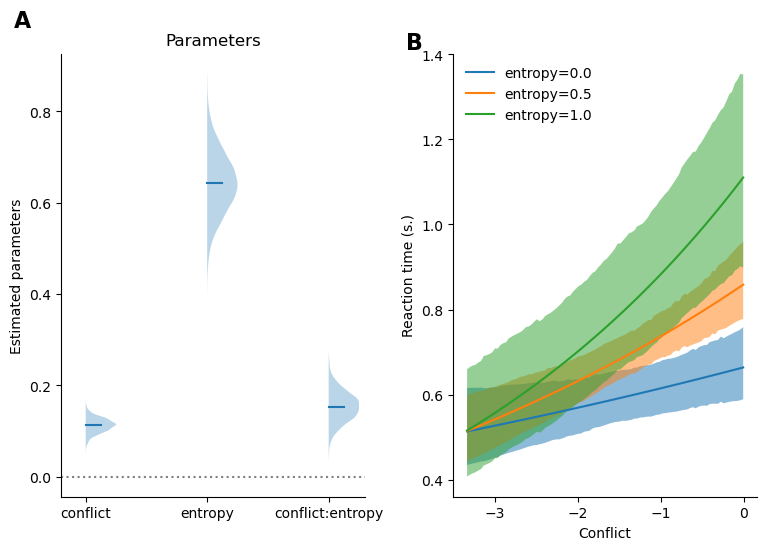

In [108]:
#| label: fig-rt
#| fig-cap: "Results of reaction time models. (A) Comparison of the model of RT as a function of decision values and intermediate offer against the model of RT
#| as a function of decision values and preferences. (B) Posterior distribution of the fitted parameter. (C) Posterior predictive curve depicting the predicted
#| reaction time as a function of the conflict values, separately for preference entropy of 0, 0.5 and 1.0"
fig, ax = plt.subplot_mosaic("AB", figsize=[A4_inches[0], 0.5*A4_inches[1]])#, gridspec_kw=dict(width_ratios=[0.5, 1]))
# ================================================
# fig-2A: model comparison:
# elpd_loo bar plot with error bar
#ax["A"].bar(    
#    list(traces_RT.keys()),
#    rt_model_comparison["elpd_loo"],
#    yerr=rt_model_comparison["se"],
#    color=cmap([1, 2])
#)
# Decoration
#ax["A"].set_xticklabels(ax["A"].get_xticklabels(), 
#                        rotation=15, ha='right')
#ax["A"].set_ylabel("ELPD (LOO)")
#ax["A"].set_ylim([-6750, -5000])
#ax["A"].set_title("Model comparison")
#ax["A"].spines[['right', 'top']].set_visible(False)
#ax["A"].text(-0.1, 1.05, "A", transform=ax["A"].transAxes, 
#              fontsize=16, fontweight='bold', va='top', ha='right'
#              )

# ================================================
# fig-B: Plot the preferences parameters of the preference & conflict model:
# Create new axes
params = [
    "conflict", "entropy", "conflict:entropy"
]
x_labels = ["conflict", "entropy", "conflict:entropy"]

ax["A"].set_ylabel("Estimated parameters")
data = []
for var in params:
    vals = traces_RT['RT = Conflict x H(Pref)'].posterior[var].values.flatten()
    data.append(vals)
ax["A"].violinplot(data, positions=range(len(params)), 
                    showmeans=False,
                    showmedians=True,
                    showextrema=False,
                    side="high");
ax["A"].set_xticks(range(len(params)))
ax["A"].set_xticklabels(x_labels)
ax["A"].spines[['right', 'top']].set_visible(False)
ax["A"].set_title("Parameters")
ax["A"].hlines(0, -0.2, 2.3, color='gray', linestyles=':')
ax["A"].set_xlim([-0.2, 2.3])
ax["A"].text(-0.1, 1.1, "A", transform=ax["A"].transAxes, 
                fontsize=16, fontweight='bold', va='top', ha='right'
                ) 

# ================================================
# fig-C: Plot the preferences parameters of the preference & conflict model:
pred_df = bmb.interpret.predictions(
    interaction_rt_model,
    traces_RT['RT = Conflict x H(Pref)'],
    conditional={
        "conflict": np.linspace(beh_data['conflict'].min(), beh_data['conflict'].max(), 100),
        "entropy": [0, 0.5, 1]
    },
)
pred_df["RT"] = np.exp(pred_df["estimate"])
pred_df["RT_low"] = np.exp(pred_df["lower_3.0%"])
pred_df["RT_up"] = np.exp(pred_df["upper_97.0%"])

for ent in pred_df["entropy"].unique():
    subset = pred_df[pred_df["entropy"] == ent]
    ax["B"].plot(subset["conflict"], subset["RT"], label=f"entropy={ent}")
    ax["B"].fill_between(subset["conflict"], subset["RT_low"], subset["RT_up"], alpha=0.5)
ax["B"].spines[['right', 'top']].set_visible(False)
ax["B"].set_xlabel('Conflict')
ax["B"].set_ylabel('Reaction time (s.)')
ax["B"].legend(frameon=False)
ax["B"].text(-0.1, 1.05, "B", transform=ax["B"].transAxes, 
                fontsize=16, fontweight='bold', va='top', ha='right'
                ) 
plt.tight_layout();

## Discussion

In this paper, we investigated the systematicity in participants deviations from optimalility in a complex sequential decision making task. Our results reveal that participants choice behaviours reflects the combination of planning and task-structured preferences which are integrated in a Bayesian-like fashion, such that the certainty of the preference component modulates the extent to which participants rely on planning for making their decision. Investigations of participants RT further indicates that participants dedicate less resources in planning when their preferences are strong. Finally, exploring the impact of task features on reward maximization revealed that participants preferences are adapted to the task, enabling them to still obtain adequate returns in case planning is not feasible due to resource constraints.

Our results constitute an important reframing of participants deviation from optimal behaviour. In the literature, biases are typically considered to be maladaptive nuisance effects, leading participants to behave poorly. Our results suggest that participants preferences constitute a compact summaries of task structure that help guide behavior when exhaustive planning is costly, when there is no time or when planning comes with high uncertainty. This framing aligns with the recently proposed policy compression framework, in which it has been shown that biases towards most frequent actions are instruemntal in maximizing returns: for an agent under resource constraints, the optimal policy integrates planning with marginal action distribution under the optimal policy which constitutes participants prior over action. Our present study however extends on this idea, by showing that rather than integrating planning with state independent priors over actions, participants rely on state dependent preferences. This is an important addition to the policy compression framework, which to our knowledge as only been tested in relatively simple decision making tasks. In most complex tasks, a state independent action prior would not yield to a much better outcome than just chosing responses randomly (as was the case in our task). It is therefore likely that to solve real world, complex problems, humans are able to keep track or approximate adequate responses preferences associated with relevant dimensions of the environment to maximize their return when they are unable to obtain fully certain or accuracy planning values.

Importantly, despite the use of exhaustive planning with reinforcement learning algorithm to obtain action values in our task, it is unlikely that planning is implemented in this way in the brain, as it would be prohibitively expansive to do so for large state spaces. More biologically plausible alternatives have been proposed, such as sampling methods, reply, partial tree search and approximate value computations. We are not committed to either of these alternatives, as our main interest in the paper was to investigate the structure underlying participants deviations from planning. The observation that RT depends on the interaction between preferences strength and decision conflict suggests that whichever algorithm implements action value implementation in the brain, the extent of the computations can be controlled to obtain more or less precise estimates depending on the specific circumstances in which planning is called into action.





- Discuss bigger picture: Biases are often treated as defects, nuisance terms, or deviations from rational planning. Your results suggest a different interpretation. In complex tasks, biases may reflect priors: compact summaries of task structure that help guide behavior when exhaustive planning is costly, when there is no time, when planning comes up with high uncertainty. 
- Discuss that we don’t imply that planning is done in the exhaustive way. Planning could be implemented by sampling, replay, partial tree search, or approximate value computation.
- Discuss that we speculate that preference should read as priors and that we can’t show this here but the active inference framework offers itself here. And these are priors over policies, maybe good connection to your next point and connect to reinforcement learning findings:

- Discuss how the results relate to the notion of computational rationality and policy compression
In policy compression framework, planning is complemented by the marginal action probability which is taken to constitute a prior over action. Our use of preferences constitutes an extension to it. Instead of considering marginal probability across states, our preferences define action probability based on the structure of the task, informing the default policy of subjects beyond what is done in traditional policy compression. Or put differently, in policy compression, assuming that participants are under too much pressure to rely on planning, participants should rely on state independent action prior, which is very restrictive and probably not adaptive. It is likely that participants rely on more information to make adaptive decisions even when planning is limited. Our Preferences offer a solution to this
- Discuss how the results relate to Sarah's model (2024 PLoS CB paper) and the idea of Certainty-based stopping criterion
- Discuss how the results relate to the traditional distinction between habits and goal directed. Preferences might reflect the habit process, and our results might indicate that both modules are at play, just that planning kicks in only if habits are weak, also in line with Sarah's work on balancing habits and goal directed behaviour paper from 2021

- A limitation of the present work is we assume that preferences are fixed, thought they are likely to be dynamically updated throughout the task. Future work should aim to characterize preferences update mechanisms, by dynamically updating both the reward and transitional probabilty structure of the task, either in a gradually or chunk-wise (i.e. having separate experimental blocks with different task structures).

Similarly, Bayesian models of planning depth formalize the decision of how much to plan as a meta-decision about the value of further tree search [@kuperwajs2021planning].

## Acknowledgements

## Data and code statement
All data used in this paper were previously published as part of @ott2022forward, and are available at https://zenodo.org/records/6328296. Code can be found on github https://github.com/AlexLepauvre/state_abstraction_paper. In addition, we've created a custom toolbox to implement reinforcement learning algorithm, which can be found here: https://github.com/AlexLepauvre/state-abstraction

## References

:::{#refs}

:::